# Интерпретация

In [25]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [26]:
data_path = '/Users/ivan/IT/spbu_ml_2026/hw_interpretation/data.csv'
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()

Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error

df = data.copy()
df = df.replace(-999.0, np.nan)

target_col = "price_target"
y = df[target_col]
X = df.drop(columns=[target_col])

cat_cols = X.select_dtypes(include=["object"]).columns
for col in cat_cols:
    X[col] = X[col].astype("category").cat.codes

mask = (~X.isna().any(axis=1)) & (~y.isna()) & (y != 0)
X = X.loc[mask]
y = y.loc[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)


def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.where(y_true == 0, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denom)) * 100


models = {}

models["Linear_no_scaler"] = LinearRegression().fit(X_train, y_train)
models["Linear_std"] = LinearRegression().fit(X_train_std, y_train)

models["Lasso_no_scaler"] = Lasso(alpha=0.001, max_iter=10000).fit(X_train, y_train)
models["Lasso_std"] = Lasso(alpha=0.001, max_iter=10000).fit(X_train_std, y_train)

models["GB_no_scaler"] = GradientBoostingRegressor(max_depth=5, random_state=42).fit(
    X_train, y_train
)
models["GB_std"] = GradientBoostingRegressor(max_depth=5, random_state=42).fit(
    X_train_std, y_train
)

rows = []

for name, model in models.items():
    if name.endswith("no_scaler"):
        X_tr, X_te = X_train, X_test
    else:
        X_tr, X_te = X_train_std, X_test_std

    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)

    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)

    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)

    mape_train = mape(y_train, y_pred_train)
    mape_test = mape(y_test, y_pred_test)

    rows.append(
        {
            "model": name,
            "mse_train": mse_train,
            "mse_test": mse_test,
            "rmse_train": rmse_train,
            "rmse_test": rmse_test,
            "mape_train": mape_train,
            "mape_test": mape_test,
        }
    )

results_task1 = pd.DataFrame(rows).sort_values("mape_test")
results_task1

,model,mse_train,mse_test,rmse_train,rmse_test,mape_train,mape_test
4,GB_no_scaler,1.517236e+05,5.074273e+06,389.517090,2252.614598,0.939988,1.965357
5,GB_std,1.517236e+05,5.087830e+06,389.517090,2255.621933,0.939988,1.969091
0,Linear_no_scaler,7.911453e+06,4.418706e+06,2812.730507,2102.071926,3.666005,3.652047
1,Linear_std,7.911453e+06,4.418706e+06,2812.730507,2102.071926,3.666005,3.652047
3,Lasso_std,7.911453e+06,4.418715e+06,2812.730507,2102.073966,3.666002,3.652049
2,Lasso_no_scaler,7.911453e+06,4.418737e+06,2812.730513,2102.079316,3.665988,3.652098


## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

In [28]:
rows_norm = []

for scaler_name, (X_tr, X_te) in {
    "StandardScaler": (X_train_std, X_test_std),
    "MinMaxScaler": (X_train_mm, X_test_mm),
}.items():
    lin = LinearRegression().fit(X_tr, y_train)
    las = Lasso(alpha=0.001, max_iter=10000).fit(X_tr, y_train)
    gb = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_tr, y_train)

    for name, model in {
        "LinearRegression": lin,
        "Lasso": las,
        "GradientBoostingRegressor": gb,
    }.items():
        y_pred = model.predict(X_te)
        rows_norm.append(
            {
                "scaler": scaler_name,
                "model": name,
                "mse": mean_squared_error(y_test, y_pred),
                "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
                "mape": mape(y_test, y_pred),
            }
        )

results_task11 = pd.DataFrame(rows_norm).sort_values(["model", "scaler"])
results_task11

,scaler,model,mse,rmse,mape
5,MinMaxScaler,GradientBoostingRegressor,5.077639e+06,2253.361761,1.961833
2,StandardScaler,GradientBoostingRegressor,5.087830e+06,2255.621933,1.969091
4,MinMaxScaler,Lasso,4.418733e+06,2102.078320,3.652056
1,StandardScaler,Lasso,4.418715e+06,2102.073966,3.652049
3,MinMaxScaler,LinearRegression,4.418706e+06,2102.071926,3.652047
0,StandardScaler,LinearRegression,4.418706e+06,2102.071926,3.652047


## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

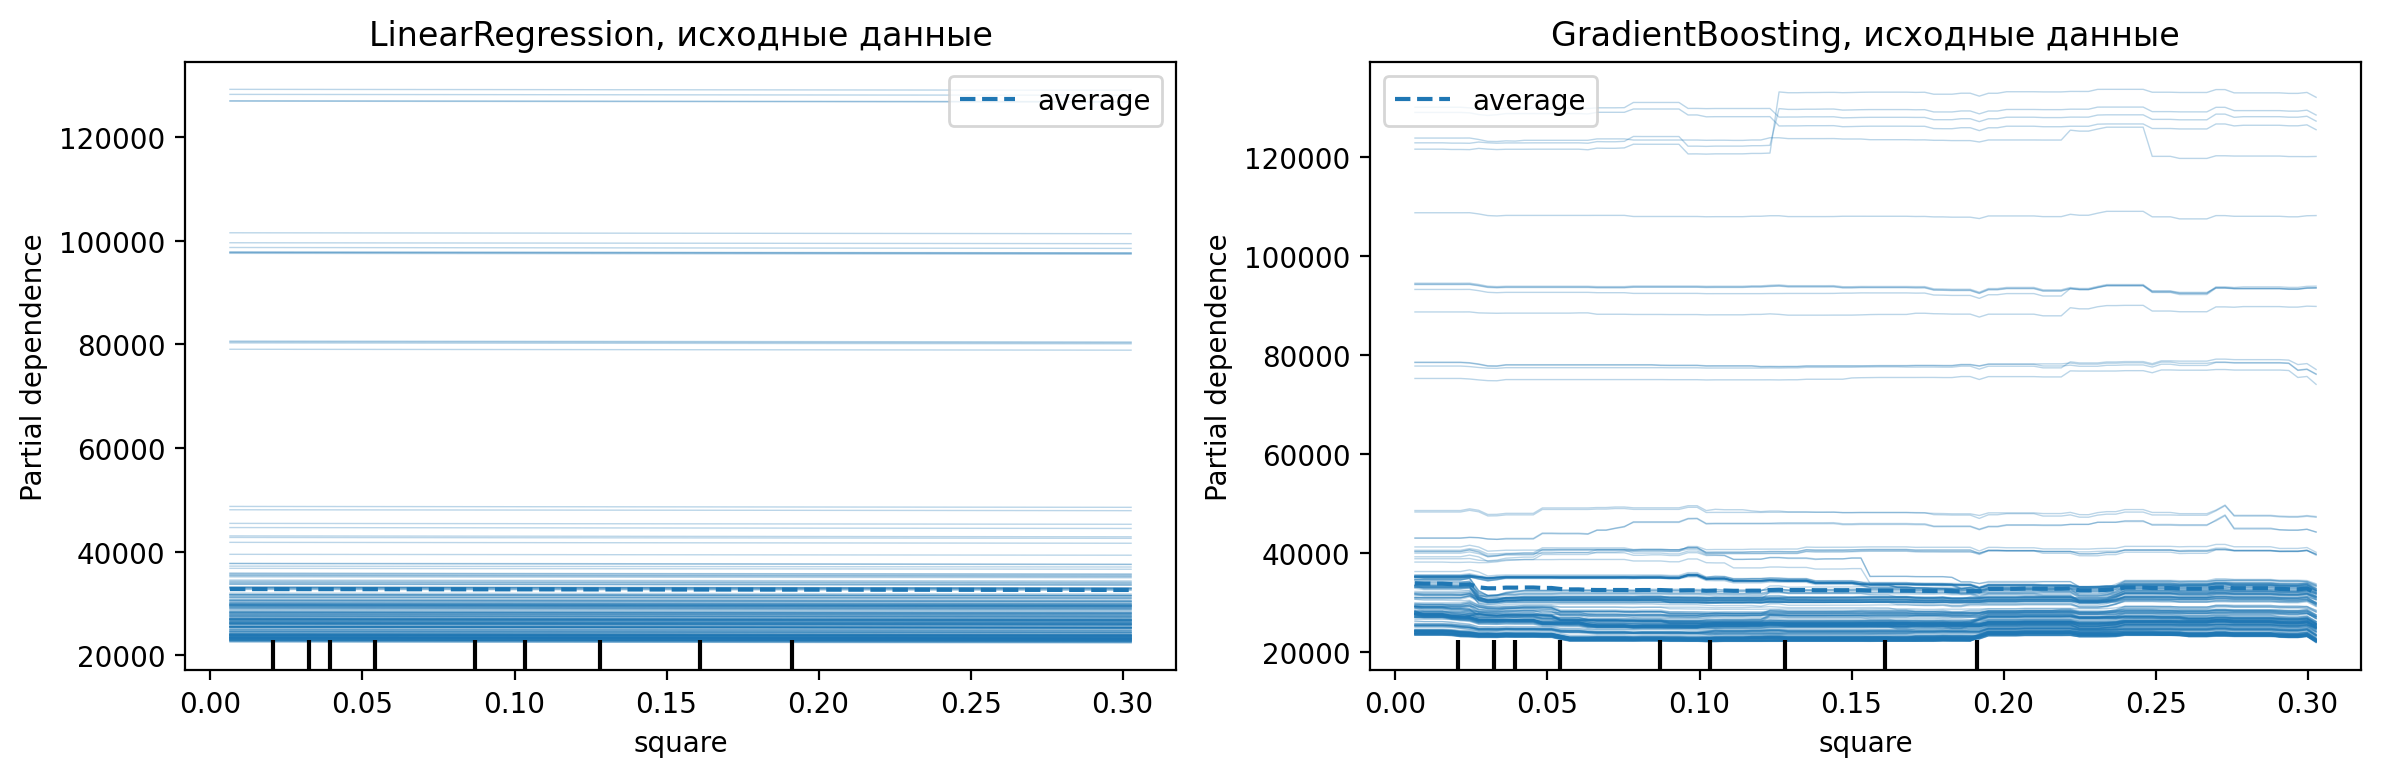

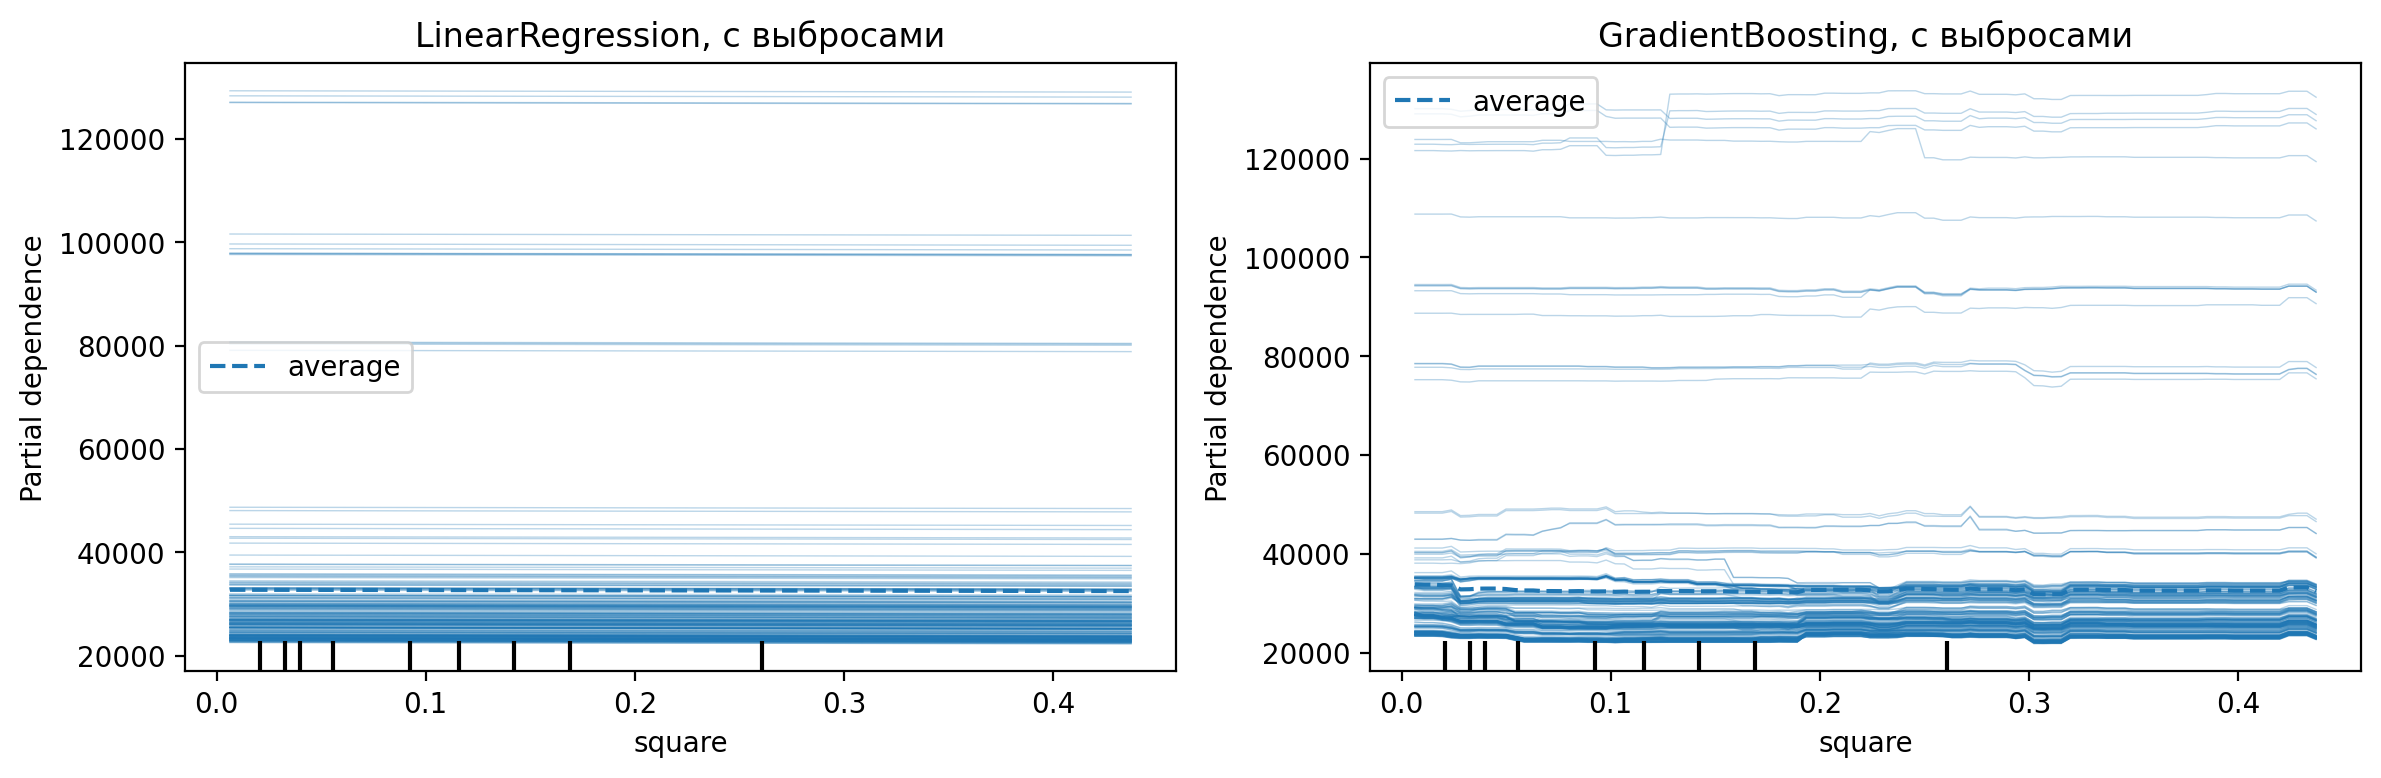

In [29]:
feature_name = "square"

lin_mm = LinearRegression().fit(X_train_mm, y_train)
gb_mm = GradientBoostingRegressor(max_depth=5, random_state=42).fit(
    X_train_mm, y_train
)

X_test_mm_df = pd.DataFrame(X_test_mm, columns=X_train.columns)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    lin_mm,
    X_test_mm_df,
    [feature_name],
    kind="both",
    ax=axes[0],
)
axes[0].set_title("LinearRegression, исходные данные")

PartialDependenceDisplay.from_estimator(
    gb_mm,
    X_test_mm_df,
    [feature_name],
    kind="both",
    ax=axes[1],
)
axes[1].set_title("GradientBoosting, исходные данные")
plt.tight_layout()

X_test_mm_out = X_test_mm_df.copy()
idx_outliers = np.random.choice(X_test_mm_out.index, size=10, replace=False)
X_test_mm_out.loc[idx_outliers, feature_name] = X_test_mm_out[feature_name].max() * 3

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    lin_mm,
    X_test_mm_out,
    [feature_name],
    kind="both",
    ax=axes[0],
)
axes[0].set_title("LinearRegression, с выбросами")

PartialDependenceDisplay.from_estimator(
    gb_mm,
    X_test_mm_out,
    [feature_name],
    kind="both",
    ax=axes[1],
)
axes[1].set_title("GradientBoosting, с выбросами")
plt.tight_layout()

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

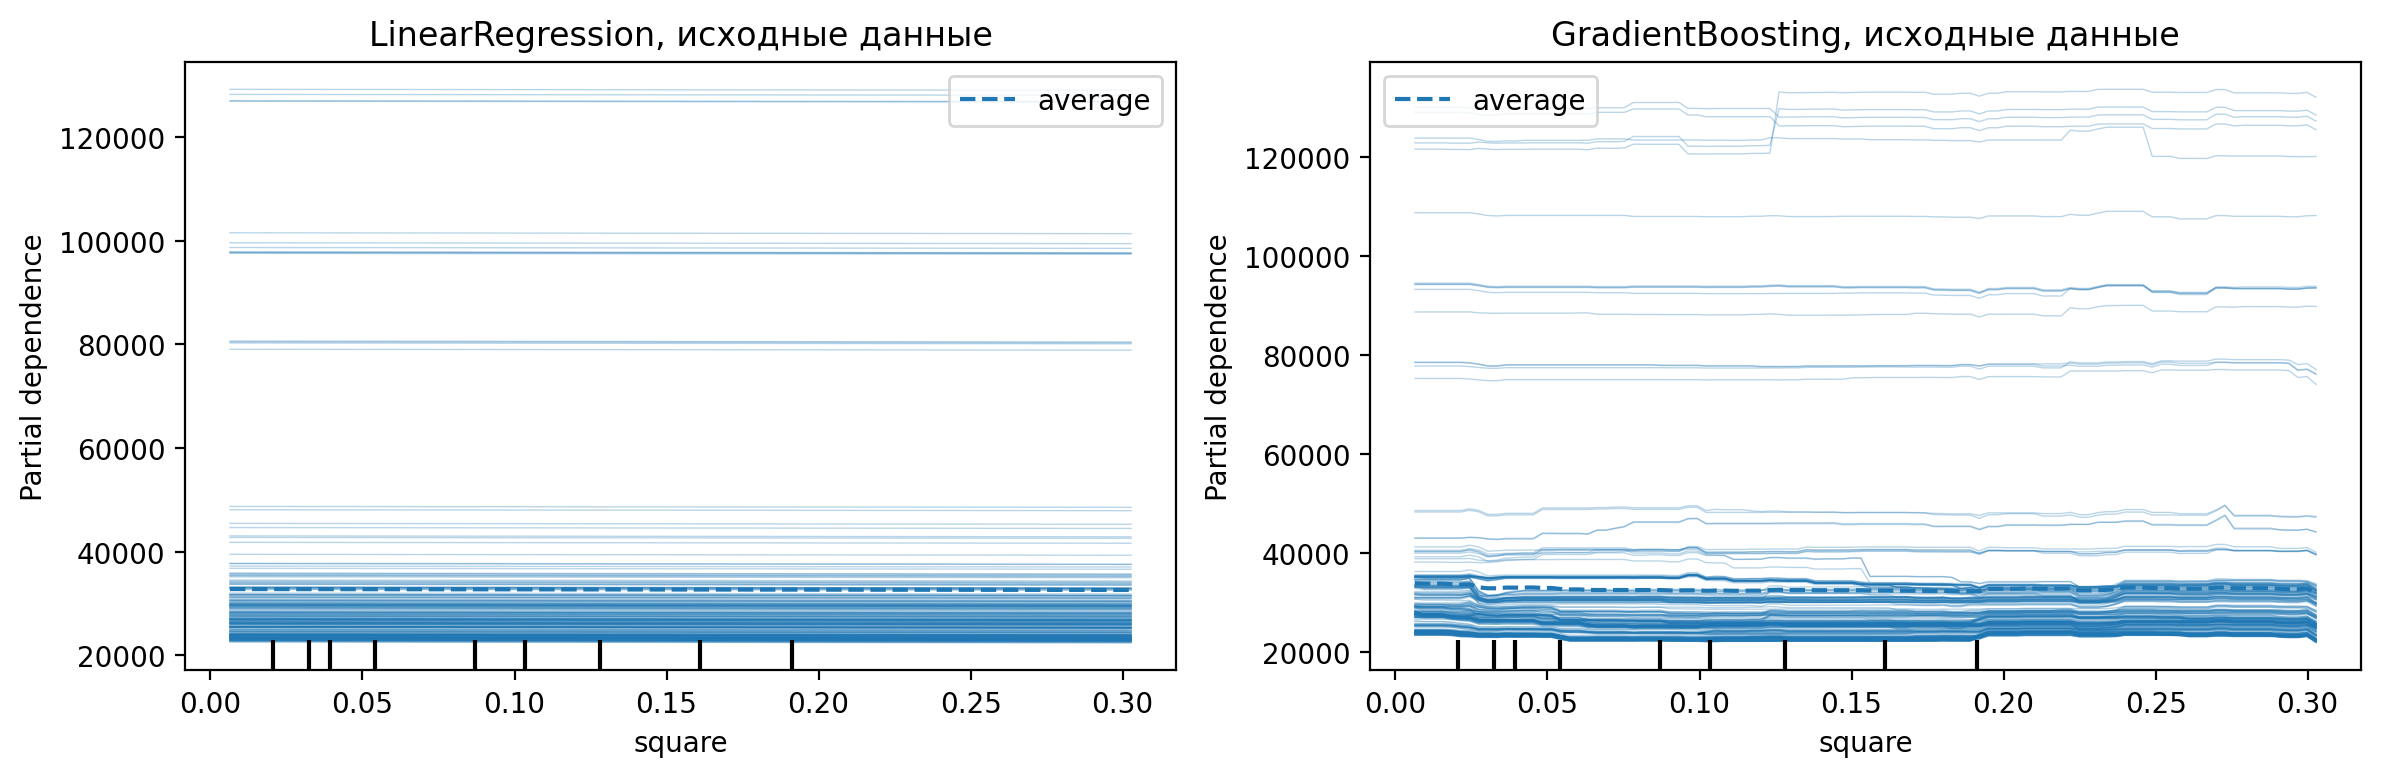

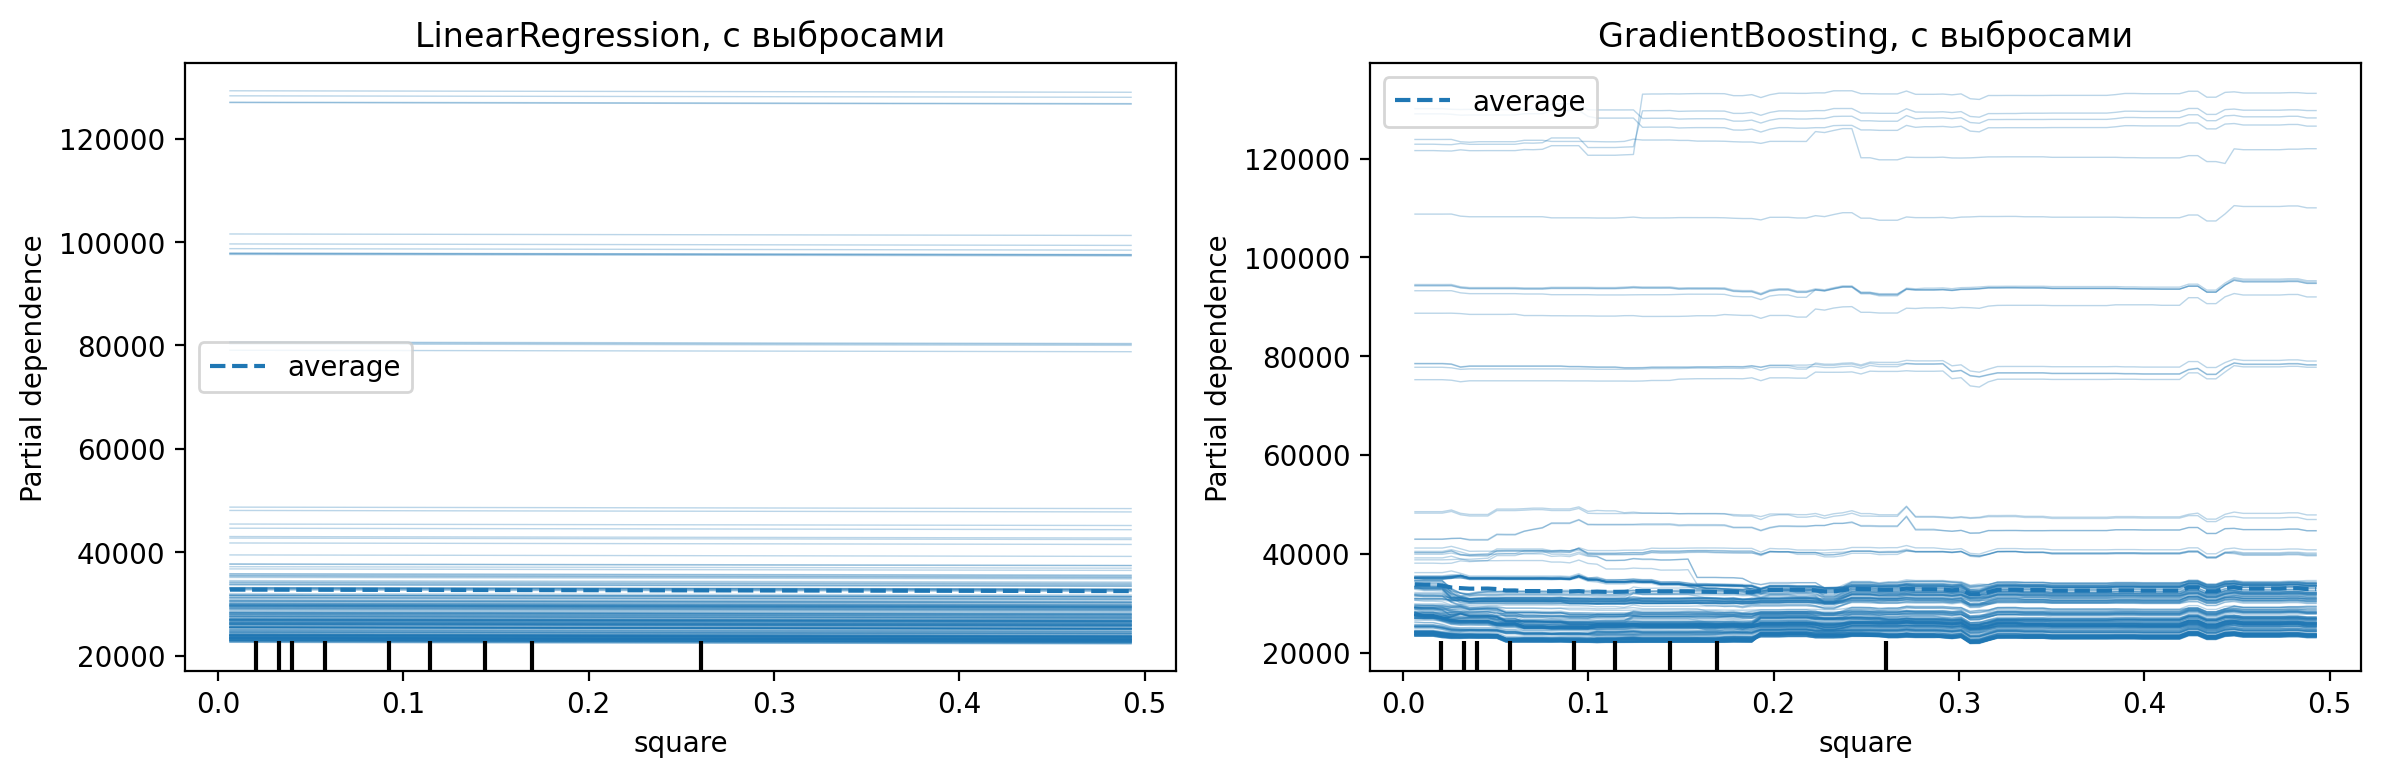

In [30]:
feature_name = "square"

lin_mm = LinearRegression().fit(X_train_mm, y_train)
gb_mm = GradientBoostingRegressor(max_depth=5, random_state=42).fit(
    X_train_mm, y_train
)

X_test_mm_df = pd.DataFrame(X_test_mm, columns=X_train.columns)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    lin_mm,
    X_test_mm_df,
    [feature_name],
    kind="both",
    ax=axes[0],
)
axes[0].set_title("LinearRegression, исходные данные")

PartialDependenceDisplay.from_estimator(
    gb_mm,
    X_test_mm_df,
    [feature_name],
    kind="both",
    ax=axes[1],
)
axes[1].set_title("GradientBoosting, исходные данные")
plt.tight_layout()

X_test_mm_out = X_test_mm_df.copy()
idx_outliers = np.random.choice(X_test_mm_out.index, size=10, replace=False)
X_test_mm_out.loc[idx_outliers, feature_name] = X_test_mm_out[feature_name].max() * 3

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    lin_mm,
    X_test_mm_out,
    [feature_name],
    kind="both",
    ax=axes[0],
)
axes[0].set_title("LinearRegression, с выбросами")

PartialDependenceDisplay.from_estimator(
    gb_mm,
    X_test_mm_out,
    [feature_name],
    kind="both",
    ax=axes[1],
)
axes[1].set_title("GradientBoosting, с выбросами")
plt.tight_layout()

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

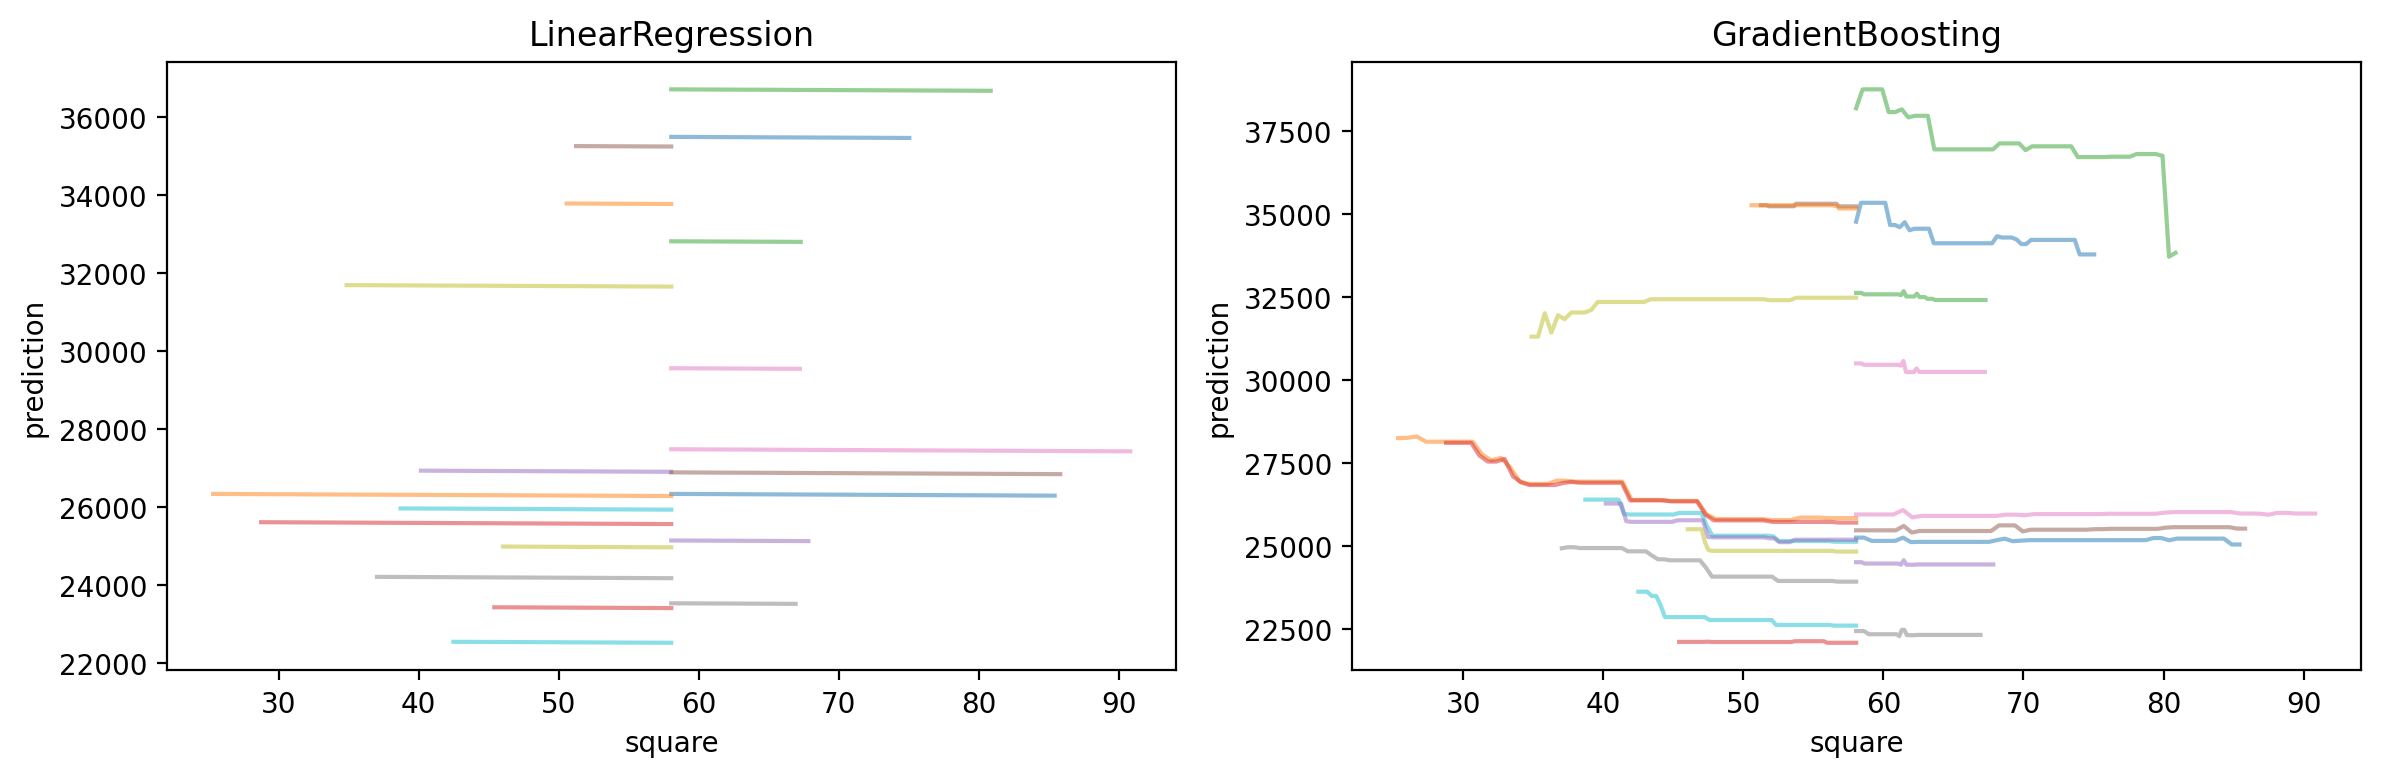

In [31]:
n_objects = 20
n_steps = 50

indices = np.random.choice(X_test.index, size=n_objects, replace=False)
base_value = X_train[feature_name].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for model, ax, title in [
    (lin_mm, axes[0], "LinearRegression"),
    (gb_mm, axes[1], "GradientBoosting"),
]:
    for idx in indices:
        x_row = X_test.loc[idx].copy()
        current_value = x_row[feature_name]
        grid = np.linspace(current_value, base_value, n_steps)
        preds = []
        for v in grid:
            x_mod = x_row.copy()
            x_mod[feature_name] = v
            x_scaled = scaler_mm.transform(x_mod.to_frame().T)
            preds.append(model.predict(x_scaled)[0])
        ax.plot(grid, preds, alpha=0.5)
    ax.set_xlabel(feature_name)
    ax.set_ylabel("prediction")
    ax.set_title(title)

plt.tight_layout()

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



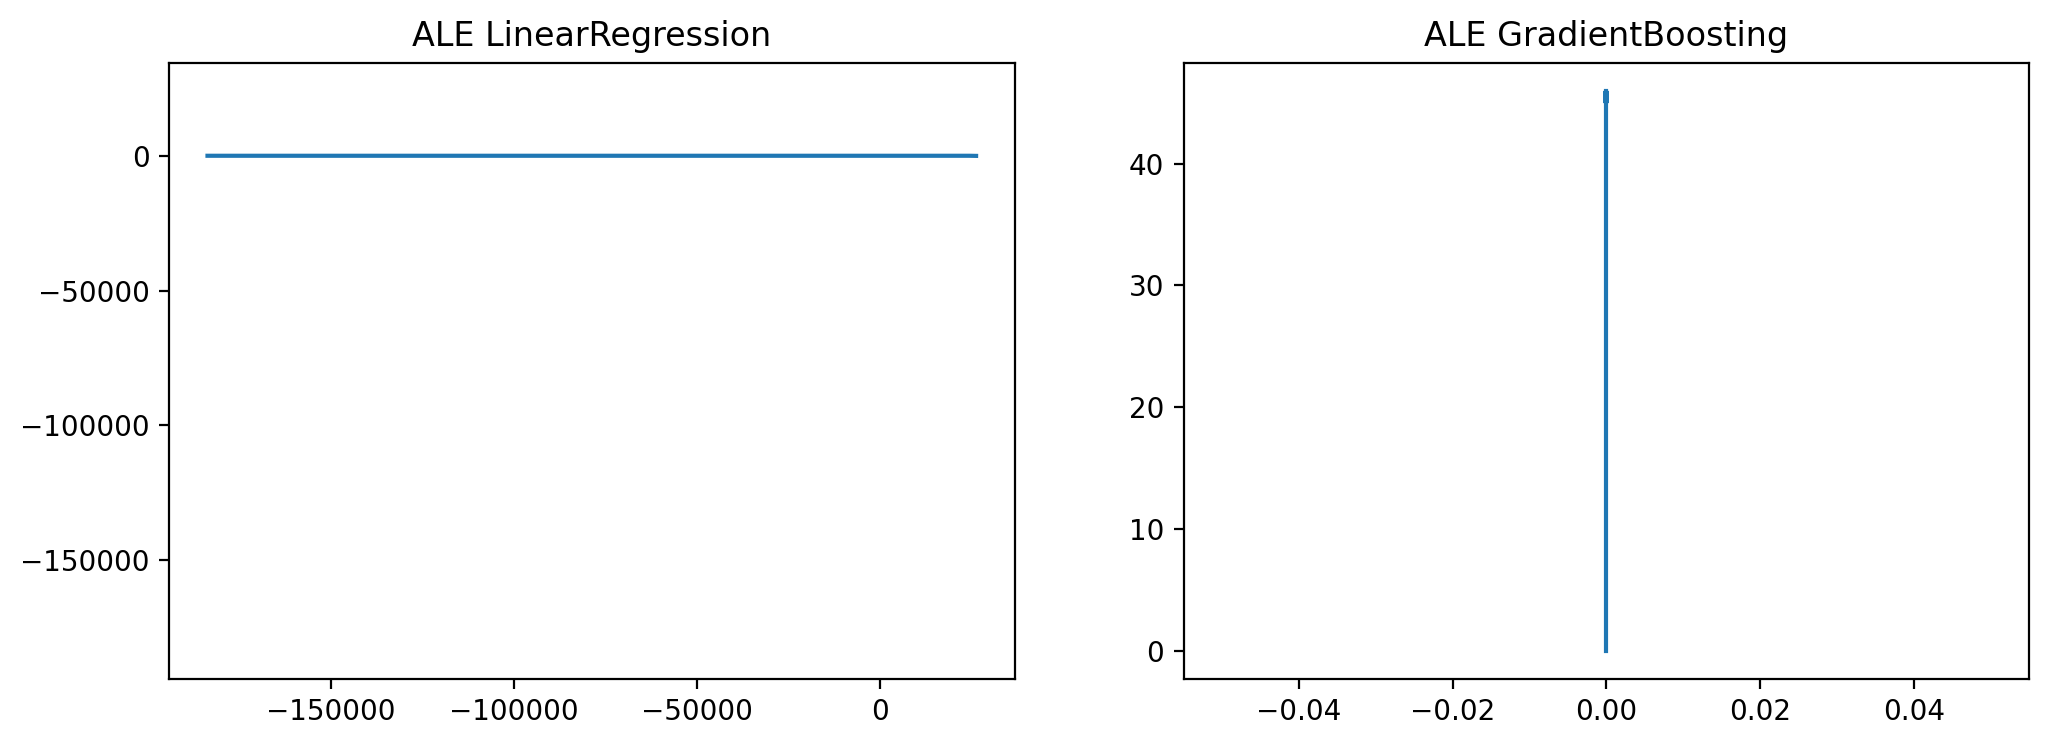

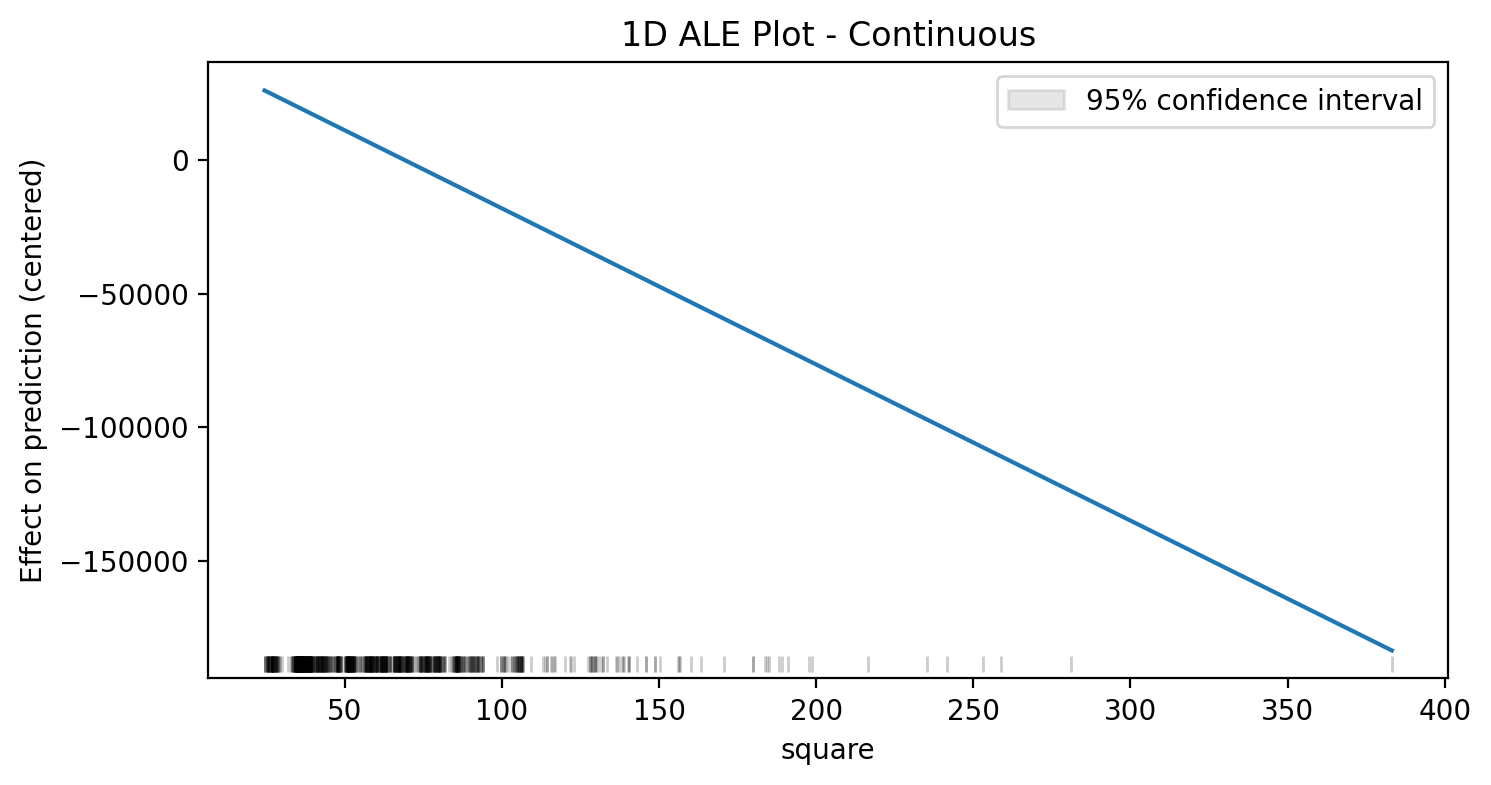

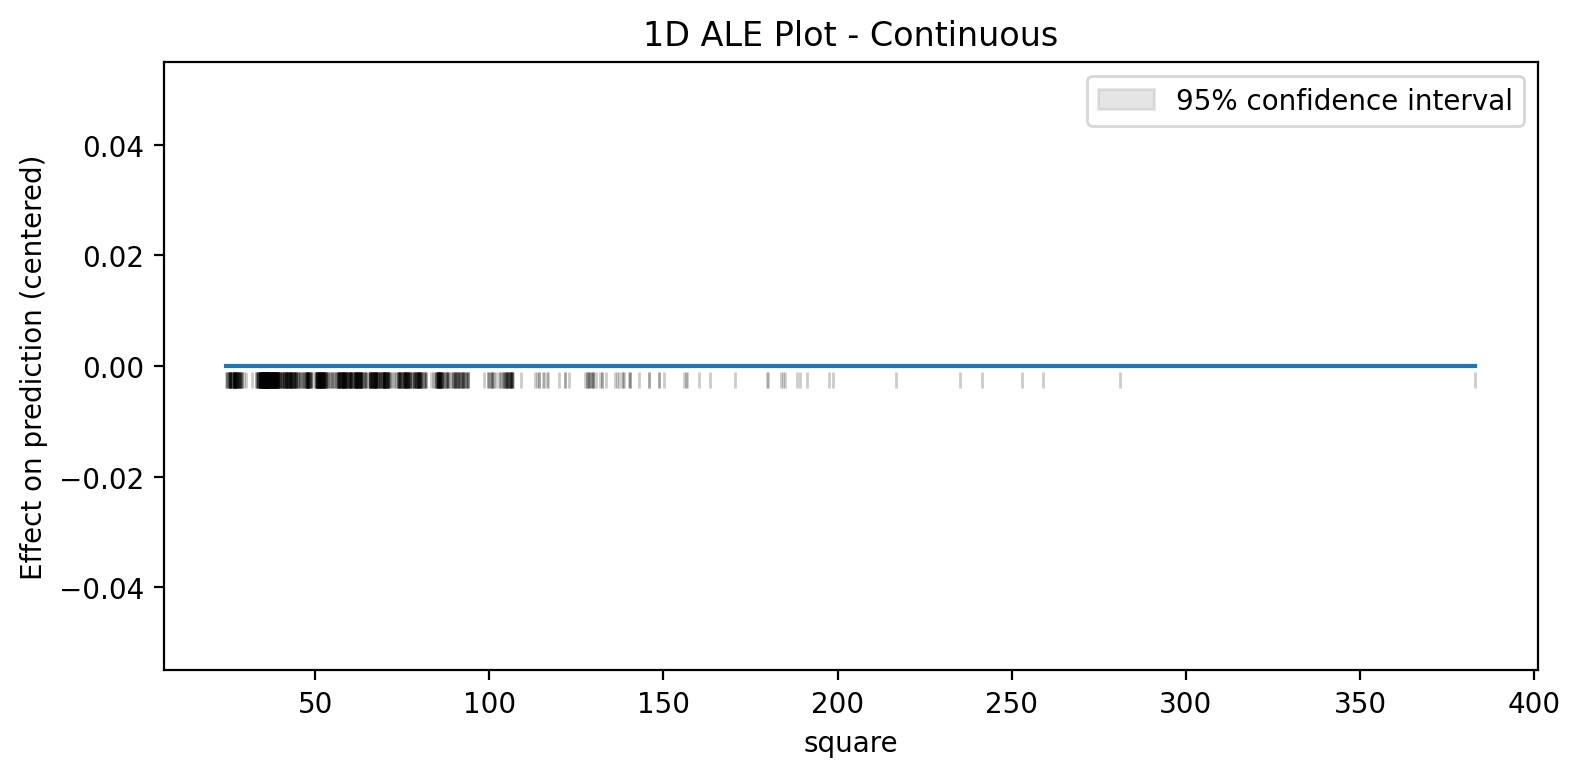

In [32]:
from PyALE import ale

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ale_lin = ale(
    X_train,
    model=lin_mm,
    feature=[feature_name],
    feature_type="continuous",
    grid_size=20,
    include_CI=True,
)

x_lin = ale_lin.iloc[:, 0]
y_lin = ale_lin.iloc[:, 1]
axes[0].plot(x_lin, y_lin, label="ALE")
if ale_lin.shape[1] >= 4:
    low_lin = ale_lin.iloc[:, 2]
    high_lin = ale_lin.iloc[:, 3]
    axes[0].fill_between(x_lin, low_lin, high_lin, alpha=0.3)
axes[0].set_title("ALE LinearRegression")

ale_gb = ale(
    X_train,
    model=gb_mm,
    feature=[feature_name],
    feature_type="continuous",
    grid_size=20,
    include_CI=True,
)

x_gb = ale_gb.iloc[:, 0]
y_gb = ale_gb.iloc[:, 1]
axes[1].plot(x_gb, y_gb, label="ALE")
if ale_gb.shape[1] >= 4:
    low_gb = ale_gb.iloc[:, 2]
    high_gb = ale_gb.iloc[:, 3]
    axes[1].fill_between(x_gb, low_gb, high_gb, alpha=0.3)
axes[1].set_title("ALE GradientBoosting")

plt.tight_layout()

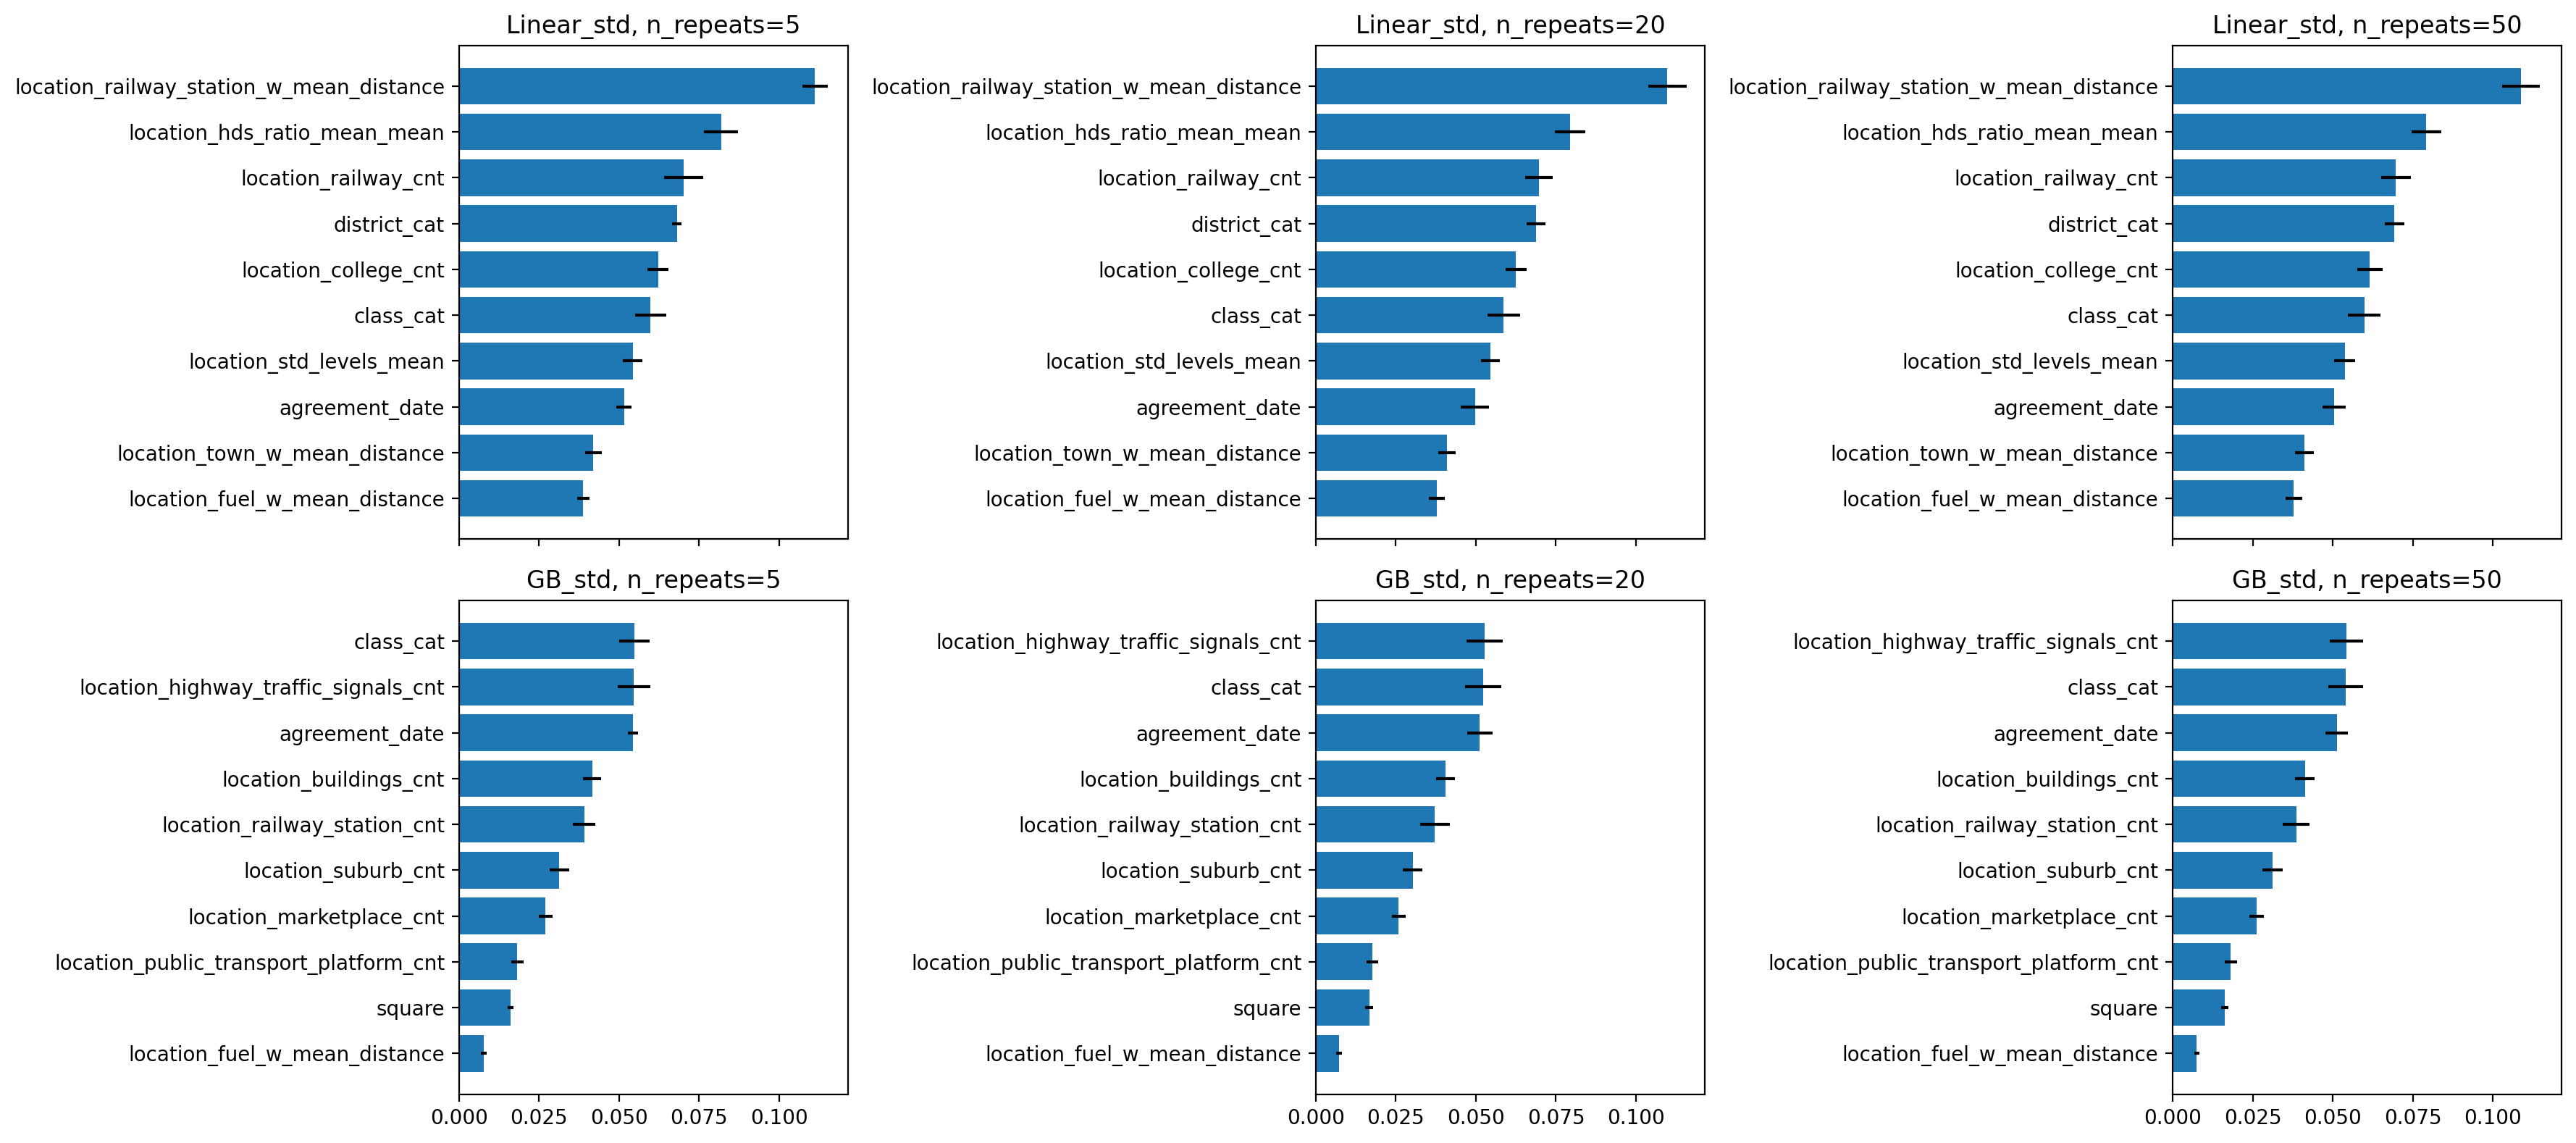

In [33]:
from sklearn.inspection import permutation_importance

perm_results = {}

for name, model, X_tr, X_te in [
    ("Linear_std", lin_mm, X_train_mm, X_test_mm),
    ("GB_std", gb_mm, X_train_mm, X_test_mm),
]:
    for n_repeats in [5, 20, 50]:
        r = permutation_importance(
            model,
            X_te,
            y_test,
            n_repeats=n_repeats,
            random_state=42,
            scoring="neg_mean_absolute_percentage_error",
        )
        perm_results[(name, n_repeats)] = r

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.ravel()

feature_names = X_train.columns

for i, ((name, n_repeats), r) in enumerate(perm_results.items()):
    idx = np.argsort(r.importances_mean)[-10:]
    axes[i].barh(
        range(len(idx)),
        r.importances_mean[idx],
        xerr=r.importances_std[idx],
        align="center",
    )
    axes[i].set_yticks(range(len(idx)))
    axes[i].set_yticklabels(feature_names[idx])
    axes[i].set_title(f"{name}, n_repeats={n_repeats}")

plt.tight_layout()

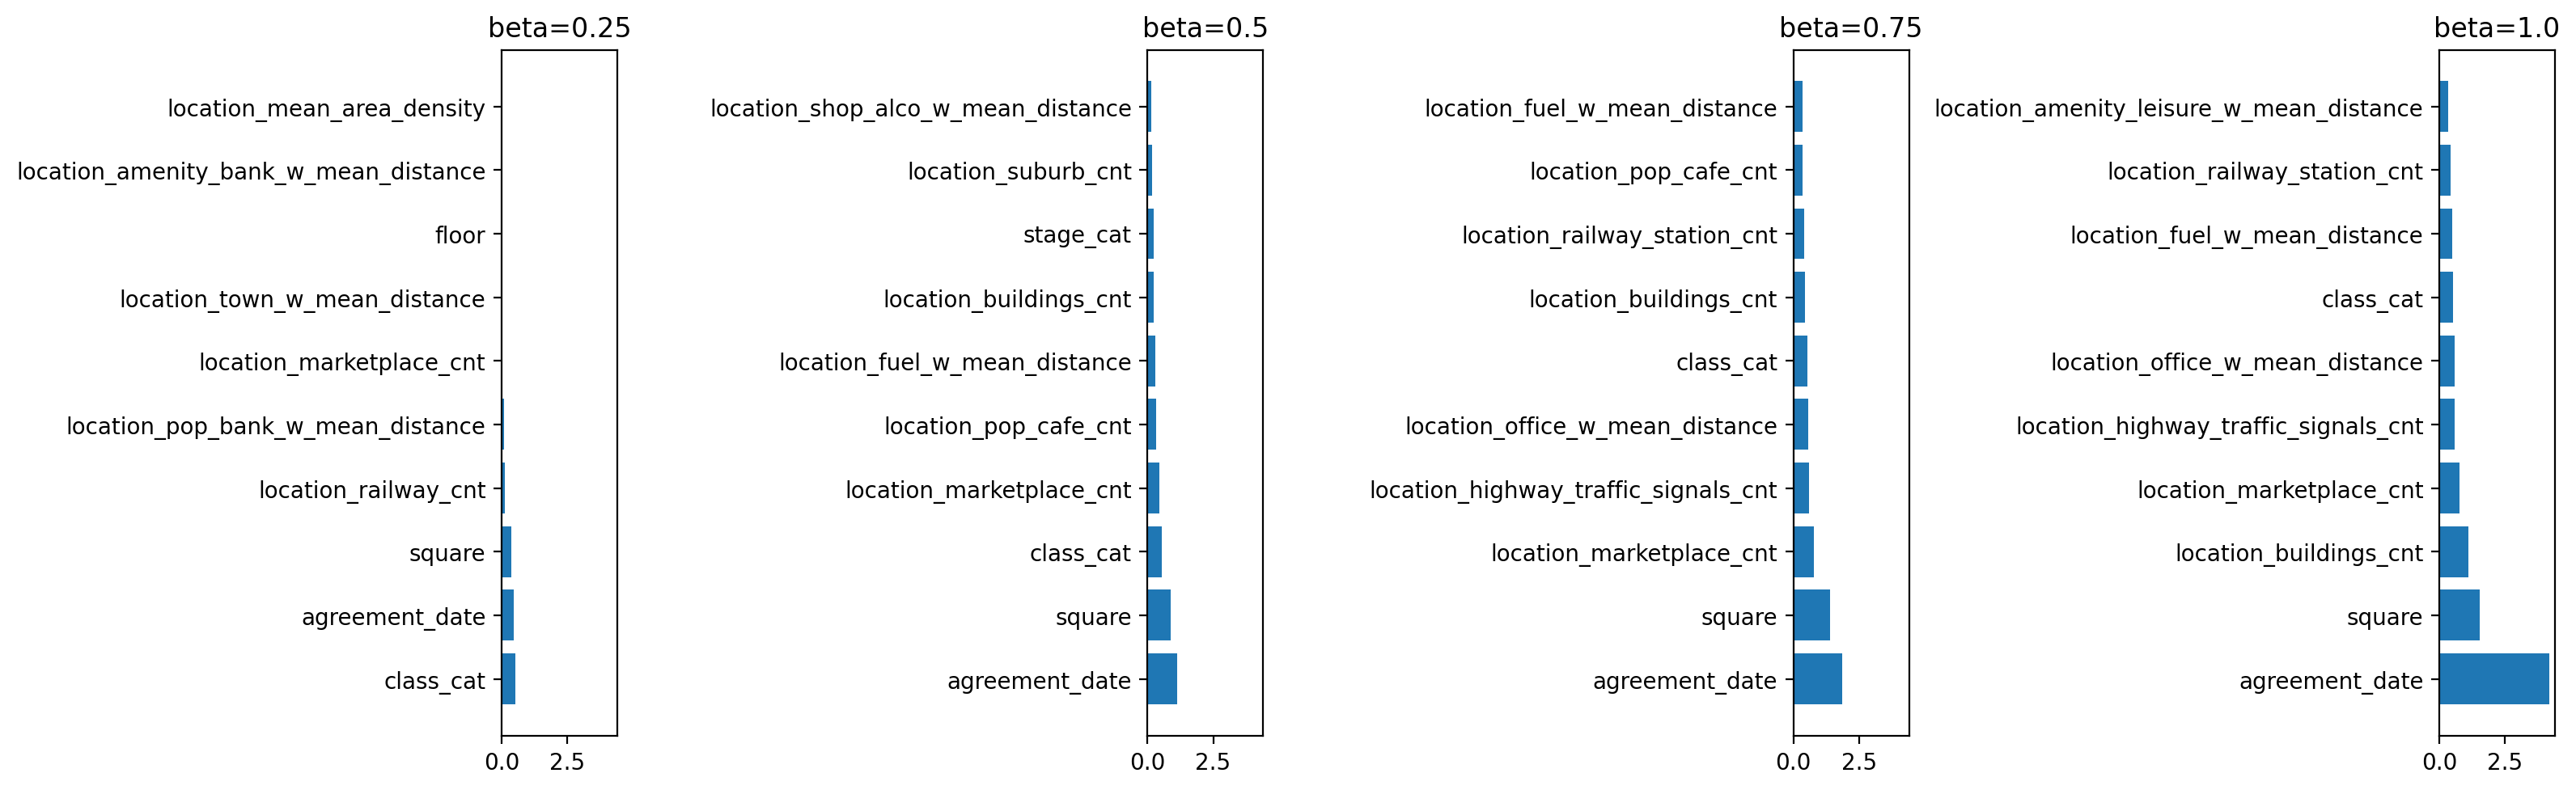

In [34]:
numeric_cols = X_train.select_dtypes(include=["number"]).columns

betas = [0.25, 0.5, 0.75, 1.0]

importance_rows = []

y_pred_base = gb_mm.predict(X_test_mm)
base_mape = mape(y_test, y_pred_base)

for beta in betas:
    for col in numeric_cols:
        X_test_perturbed = X_test.copy()
        base_val = X_train[col].median()
        X_test_perturbed[col] = (1 - beta) * X_test_perturbed[col] + beta * base_val
        X_test_perturbed_mm = scaler_mm.transform(X_test_perturbed)
        y_pred_perturbed = gb_mm.predict(X_test_perturbed_mm)
        imp = mape(y_test, y_pred_perturbed) - base_mape
        importance_rows.append({"beta": beta, "feature": col, "importance": imp})

importance_df = pd.DataFrame(importance_rows)

fig, axes = plt.subplots(1, len(betas), figsize=(4 * len(betas), 5), sharex=True)

for i, beta in enumerate(betas):
    sub = importance_df[importance_df["beta"] == beta]
    sub_sorted = sub.sort_values("importance", ascending=False).head(10)
    axes[i].barh(sub_sorted["feature"], sub_sorted["importance"])
    axes[i].set_title(f"beta={beta}")

plt.tight_layout()

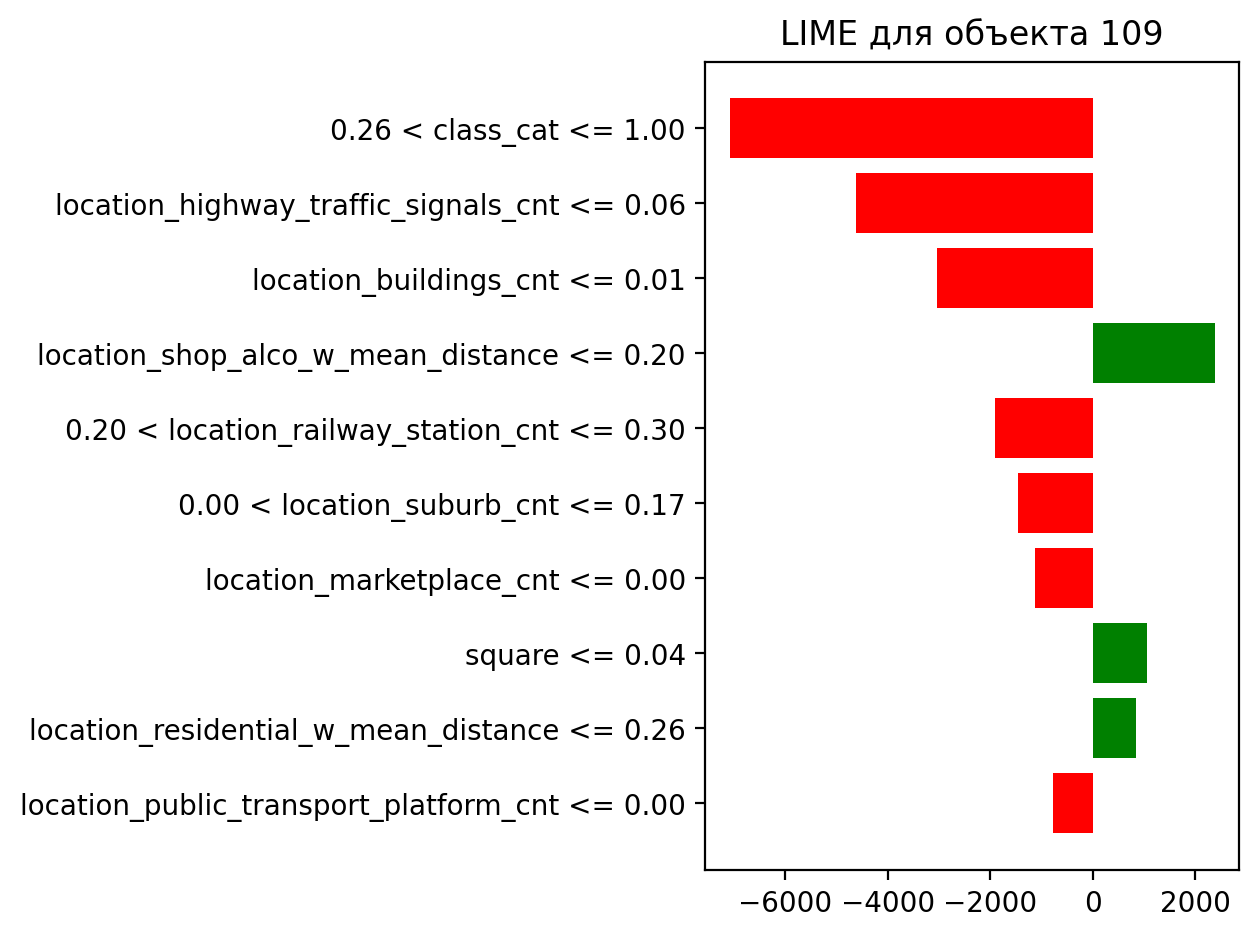

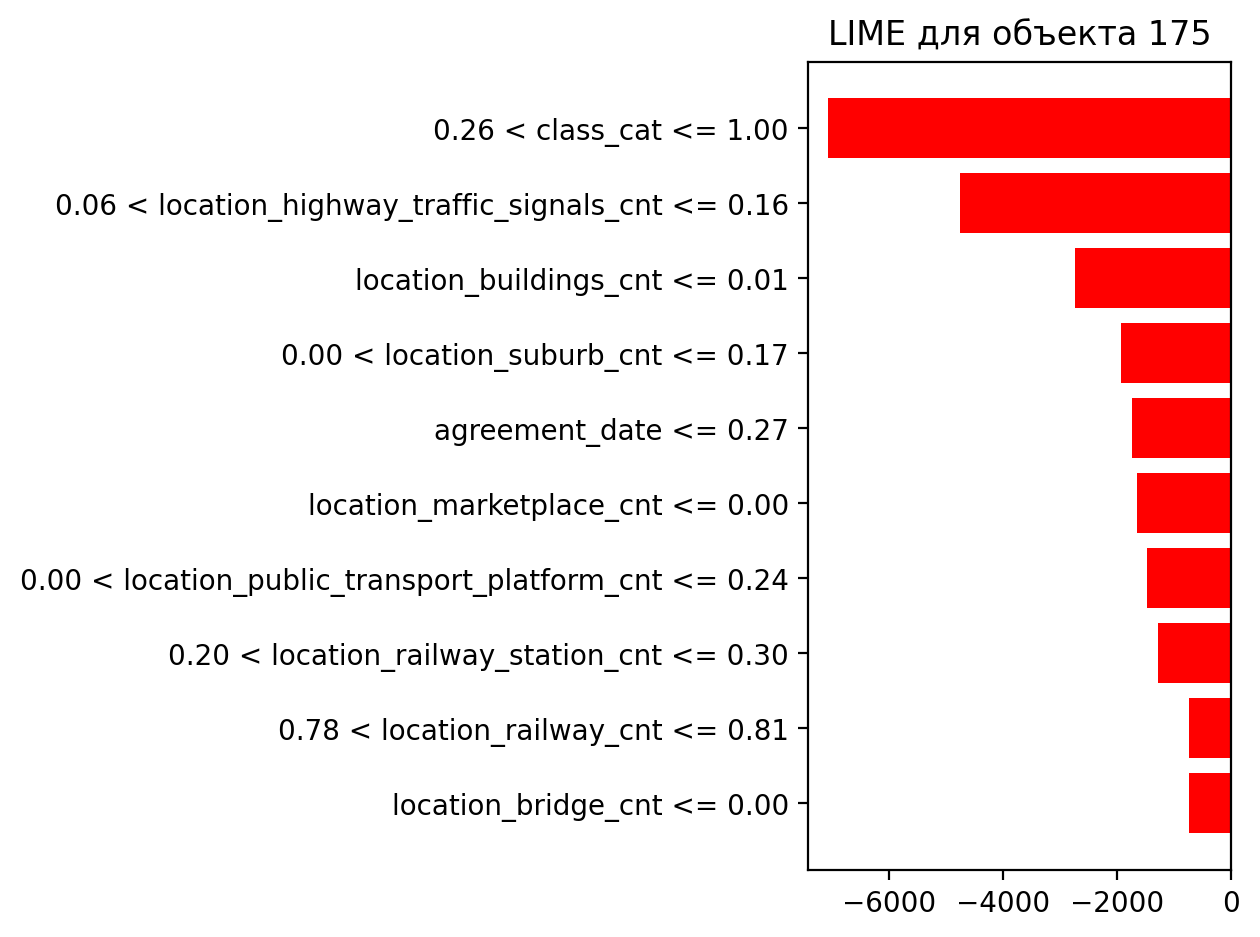

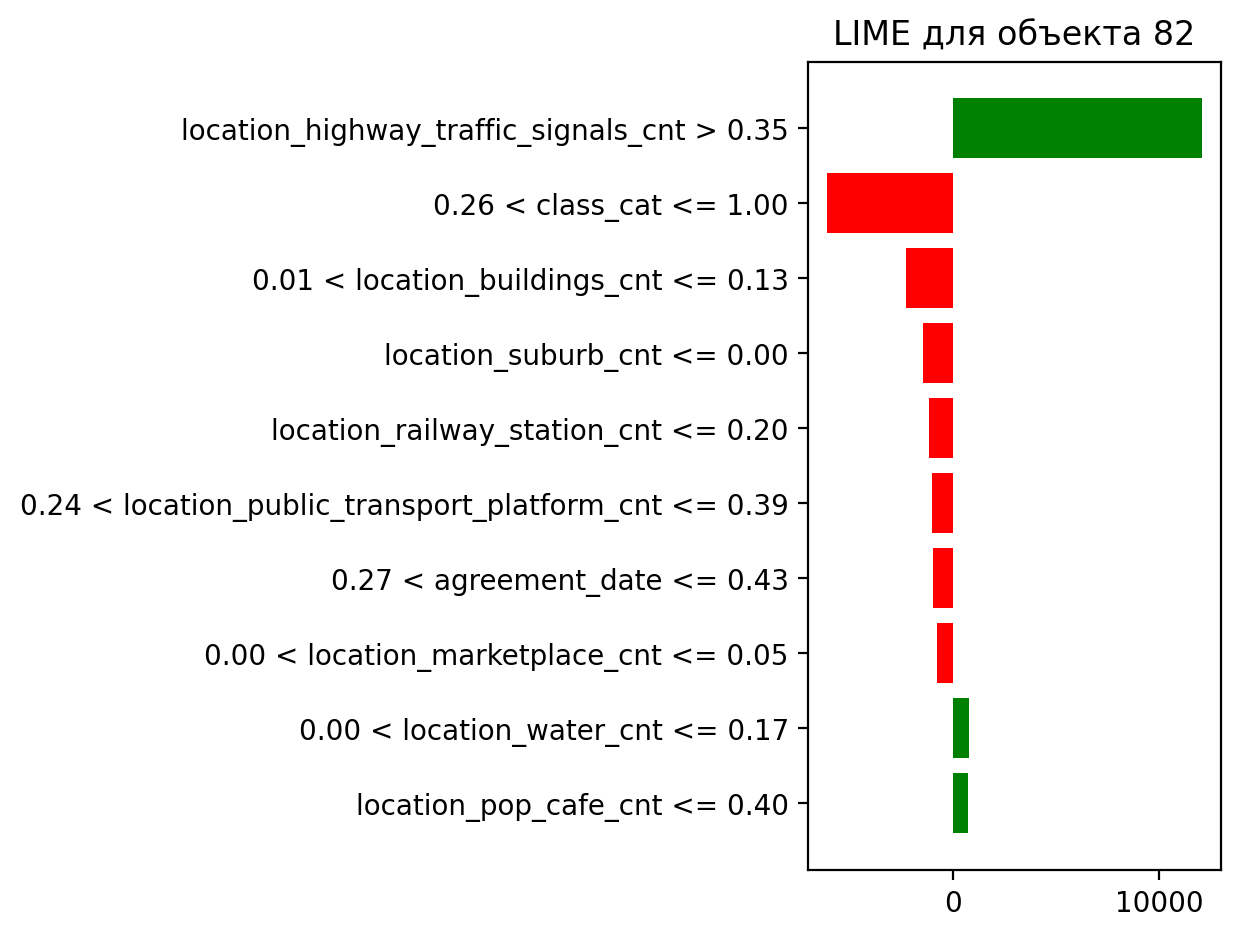

In [35]:
from lime.lime_tabular import LimeTabularExplainer

X_train_mm_array = np.array(X_train_mm)
X_test_mm_array = np.array(X_test_mm)

explainer_lime = LimeTabularExplainer(
    X_train_mm_array,
    feature_names=X_train.columns.tolist(),
    class_names=["price"],
    mode="regression",
)

indices_lime = np.random.choice(X_test_mm_array.shape[0], size=3, replace=False)

for idx in indices_lime:
    exp = explainer_lime.explain_instance(
        X_test_mm_array[idx],
        gb_mm.predict,
        num_features=10,
    )
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME для объекта {idx}")
    plt.tight_layout()
    plt.show()

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

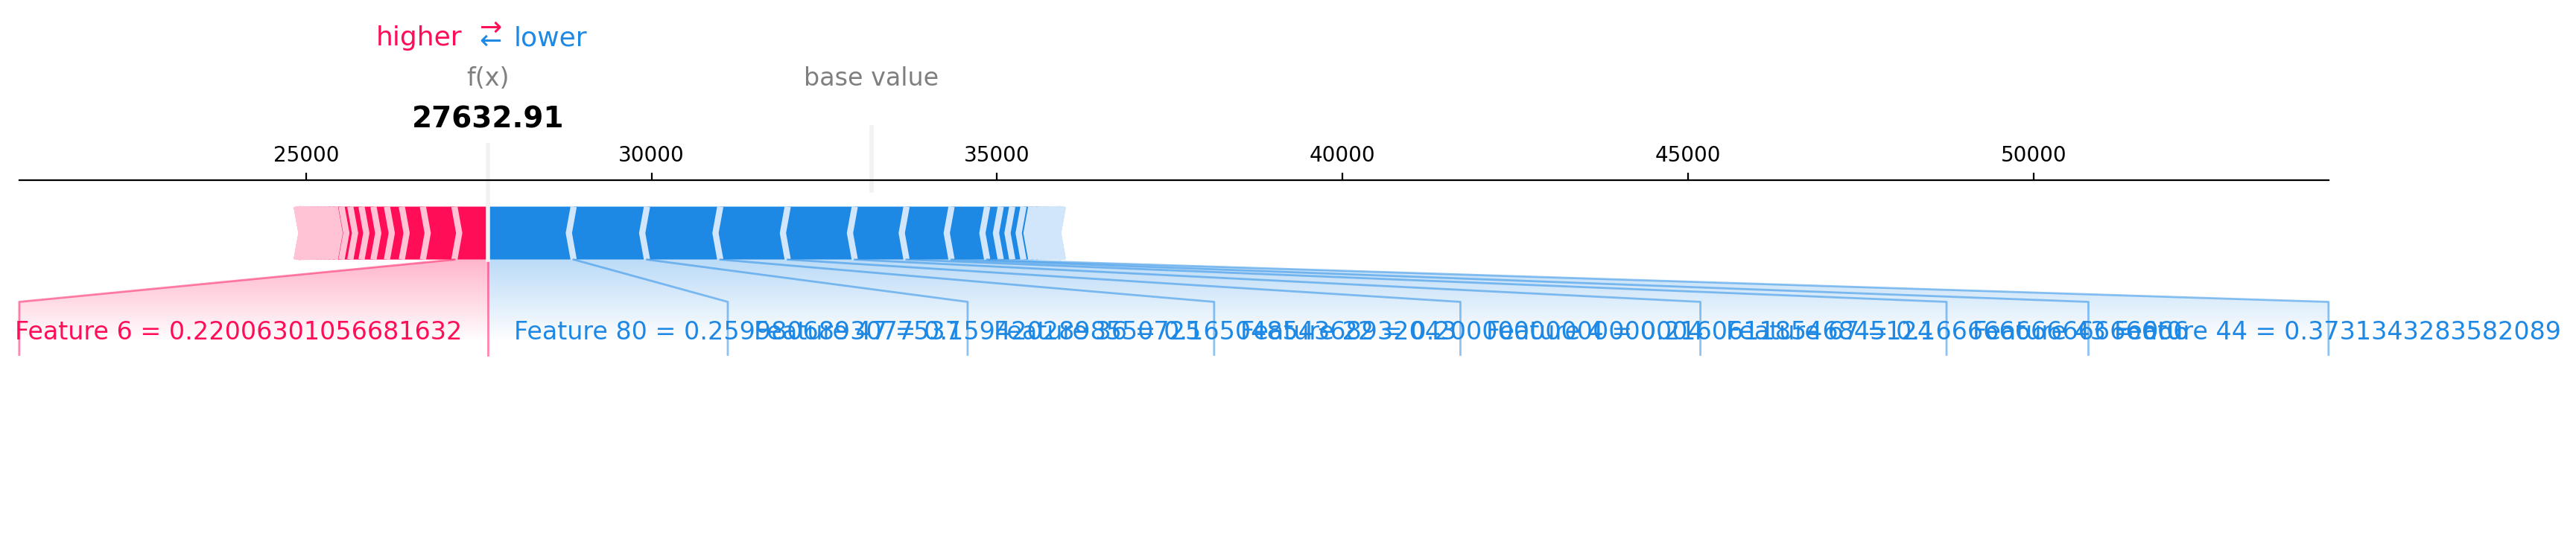

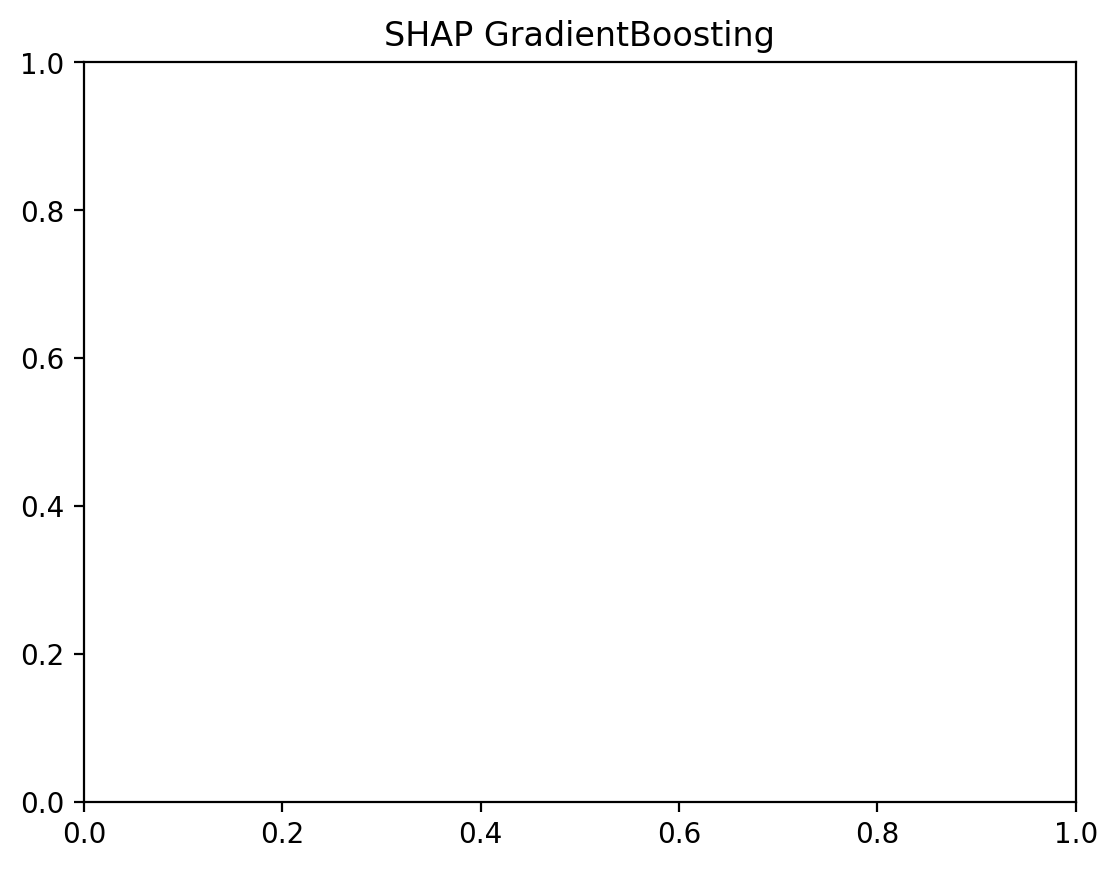

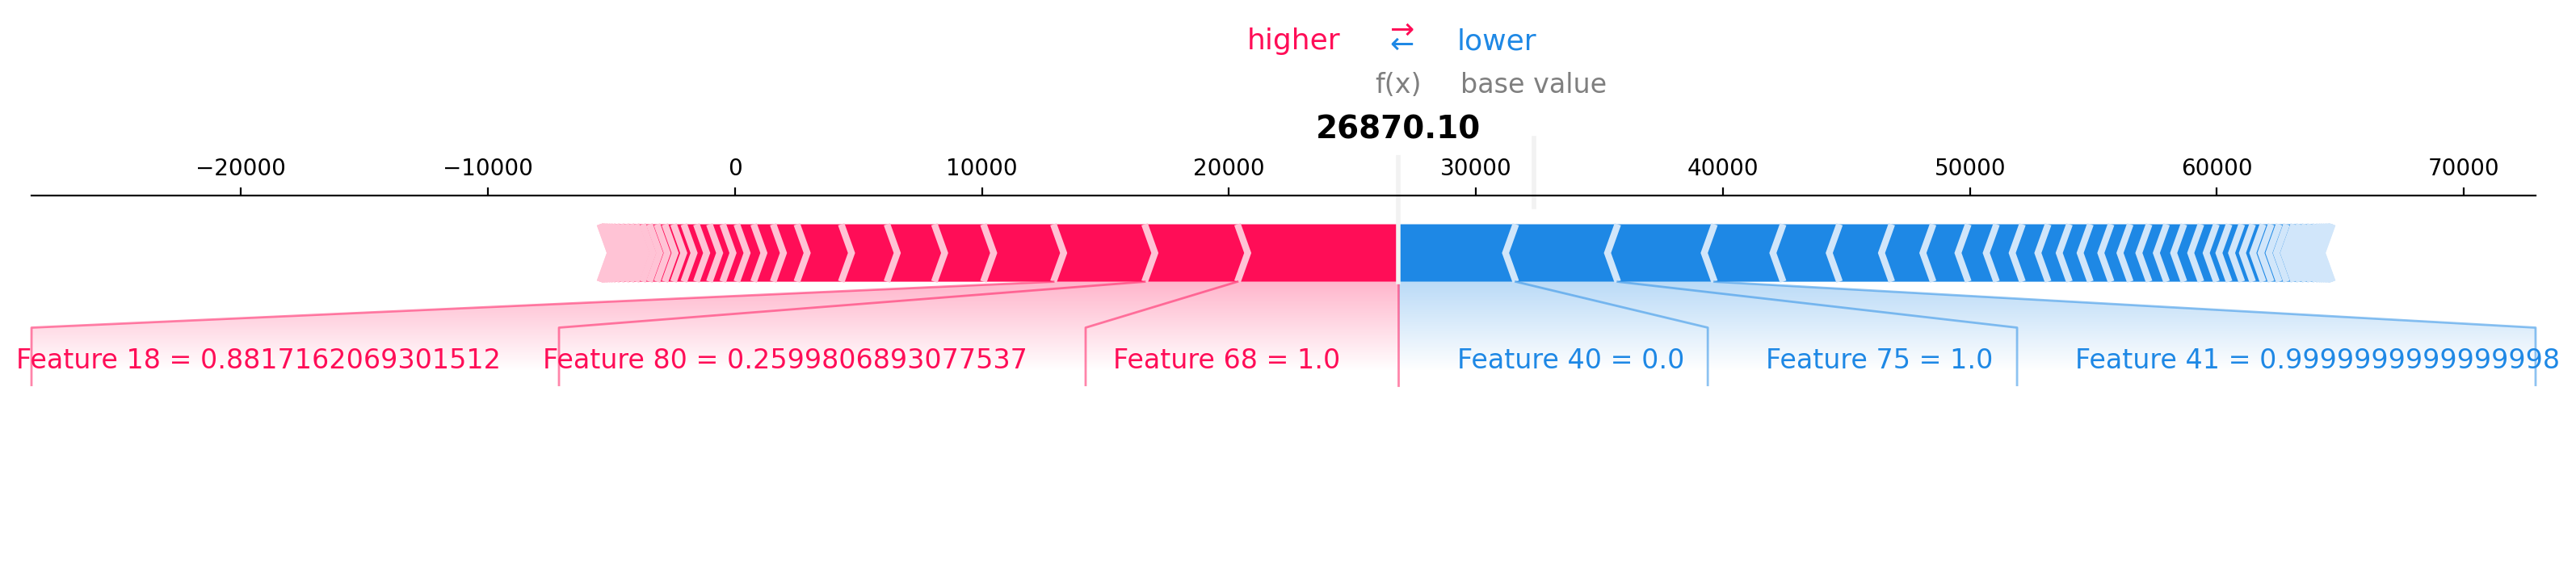

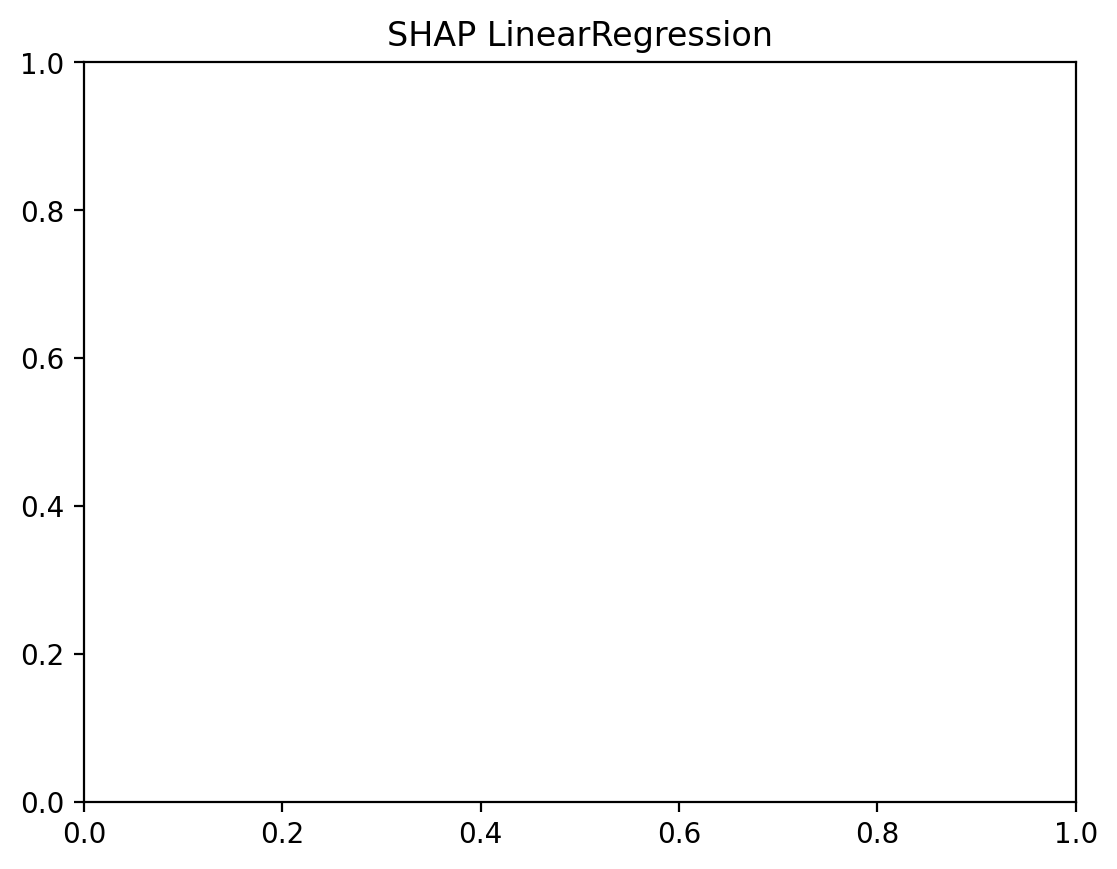

In [36]:
import shap

explainer_gb = shap.TreeExplainer(gb_mm)
explainer_lin = shap.LinearExplainer(lin_mm, X_train_mm)

student_index = 0

x_test_sample = X_test_mm[student_index : student_index + 1]

shap_values_gb = explainer_gb.shap_values(x_test_sample)
shap_values_lin = explainer_lin.shap_values(x_test_sample)

shap.initjs()

shap.force_plot(explainer_gb.expected_value, shap_values_gb, x_test_sample, matplotlib=True)
plt.title("SHAP GradientBoosting")
plt.show()

shap.force_plot(explainer_lin.expected_value, shap_values_lin, x_test_sample, matplotlib=True)
plt.title("SHAP LinearRegression")
plt.show()

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 



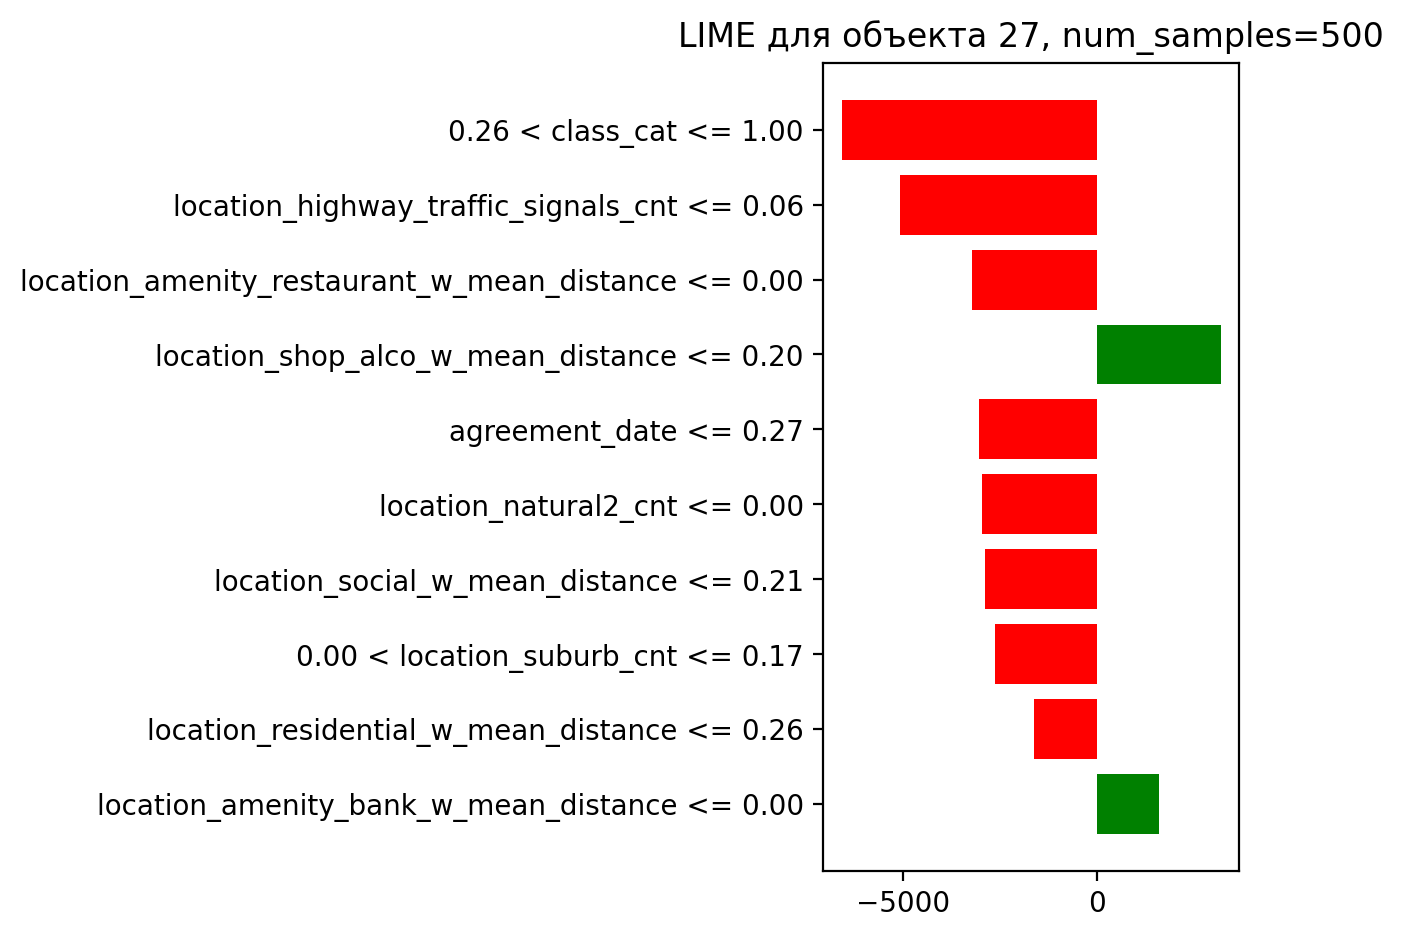

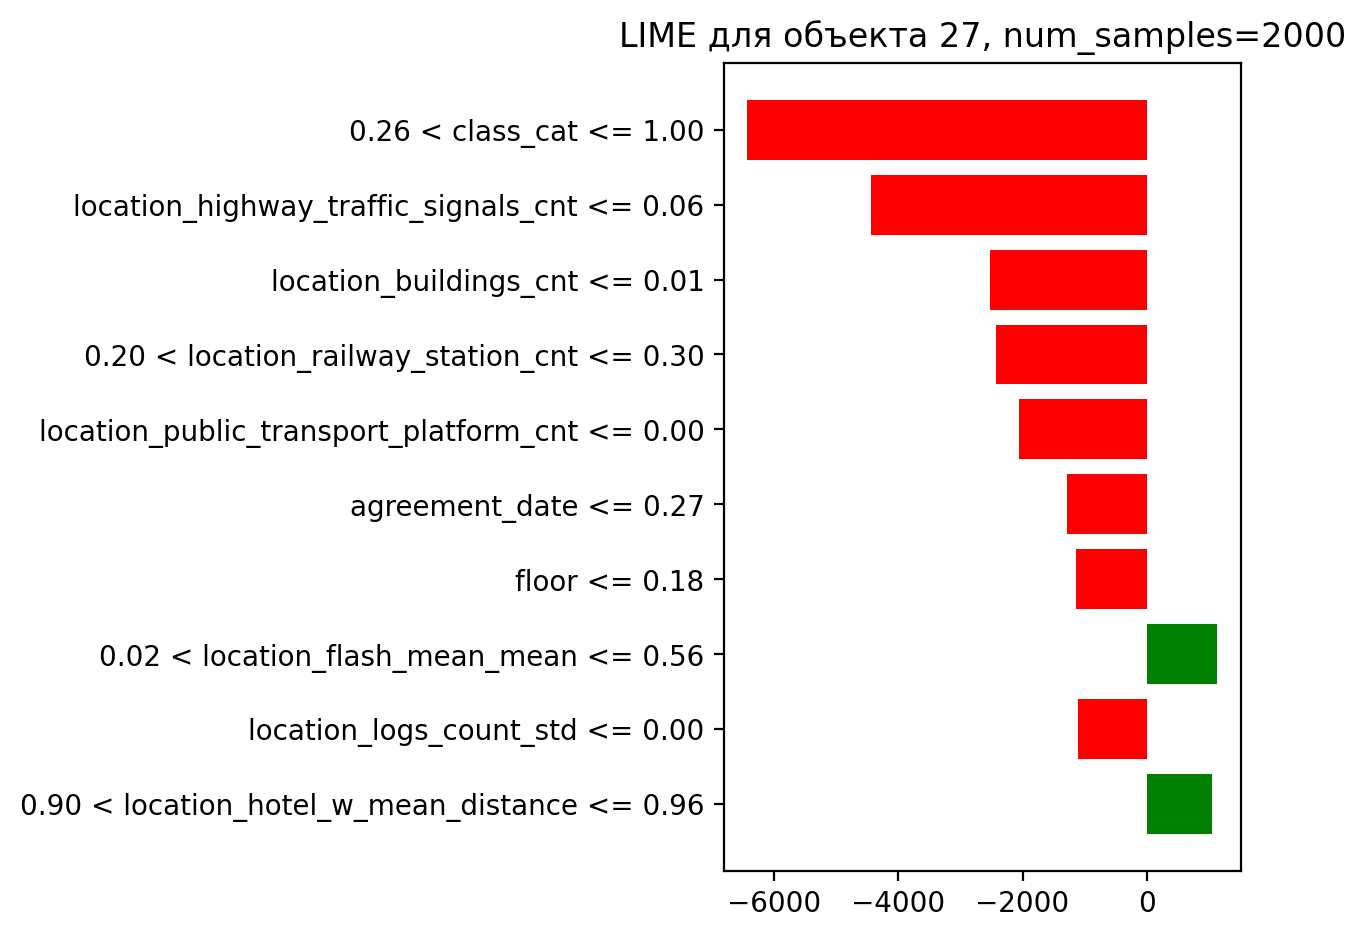

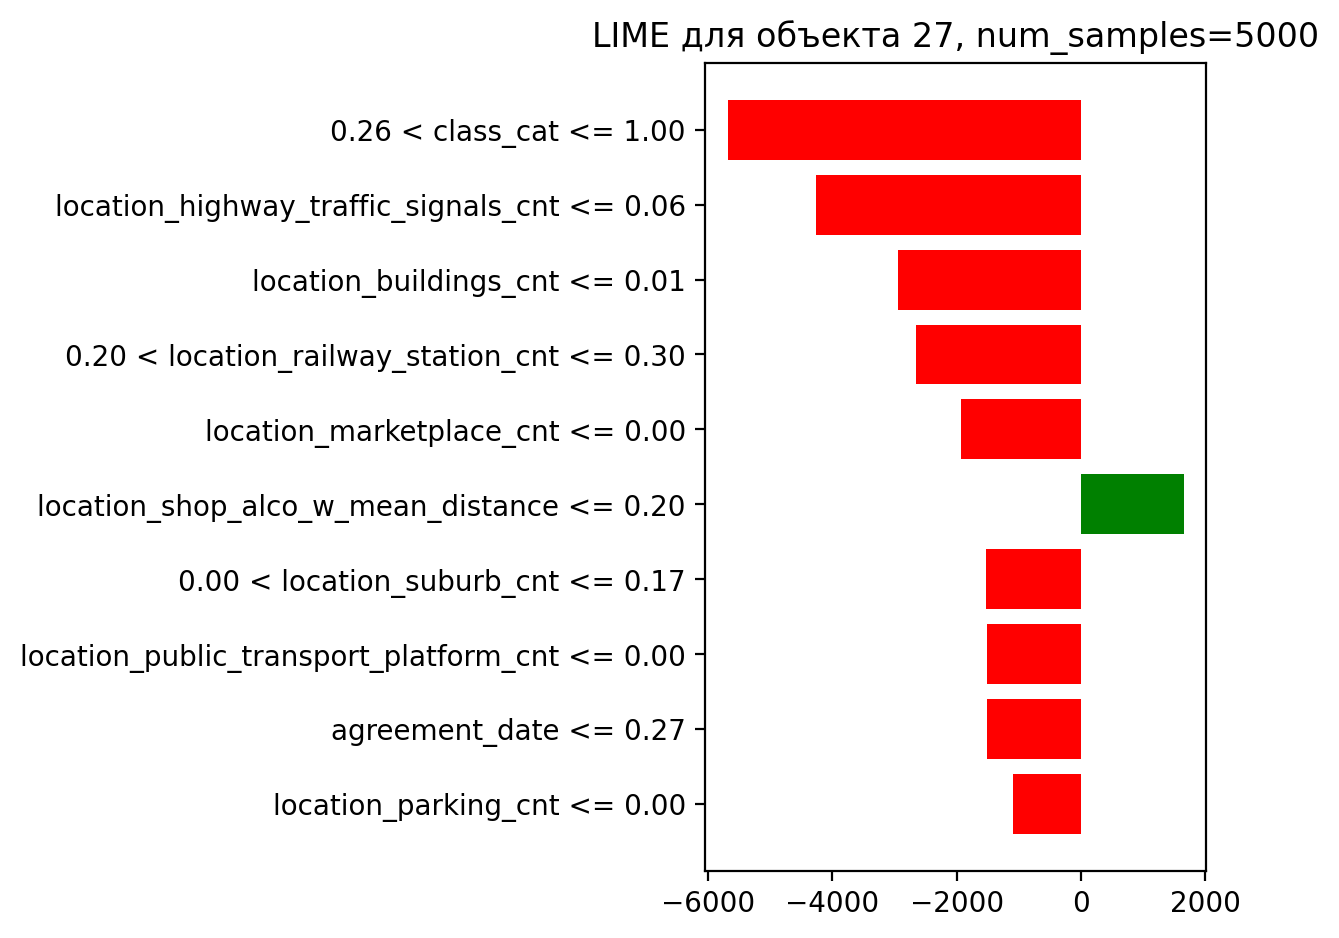

In [37]:
from lime.lime_tabular import LimeTabularExplainer

X_train_mm_array = np.array(X_train_mm)
X_test_mm_array = np.array(X_test_mm)

explainer_lime = LimeTabularExplainer(
    X_train_mm_array,
    feature_names=X_train.columns.tolist(),
    class_names=["price"],
    mode="regression",
)

idx = np.random.choice(X_test_mm_array.shape[0])

for num_samples in [500, 2000, 5000]:
    exp = explainer_lime.explain_instance(
        X_test_mm_array[idx],
        gb_mm.predict,
        num_features=10,
        num_samples=num_samples,
    )
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME для объекта {idx}, num_samples={num_samples}")
    plt.tight_layout()
    plt.show()

## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 
## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 


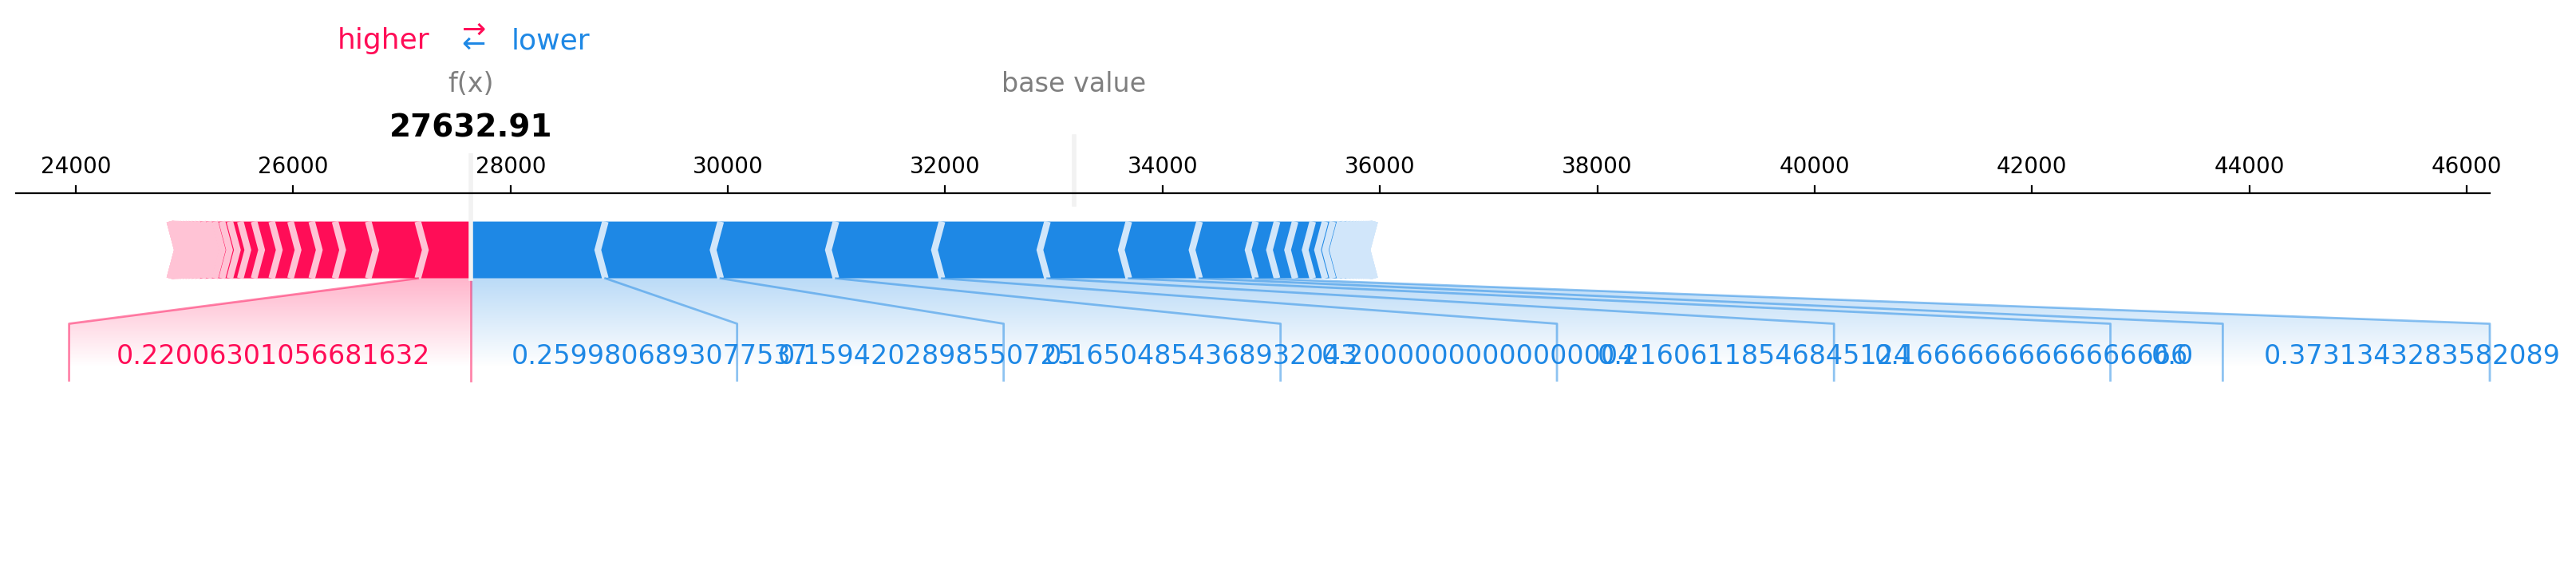

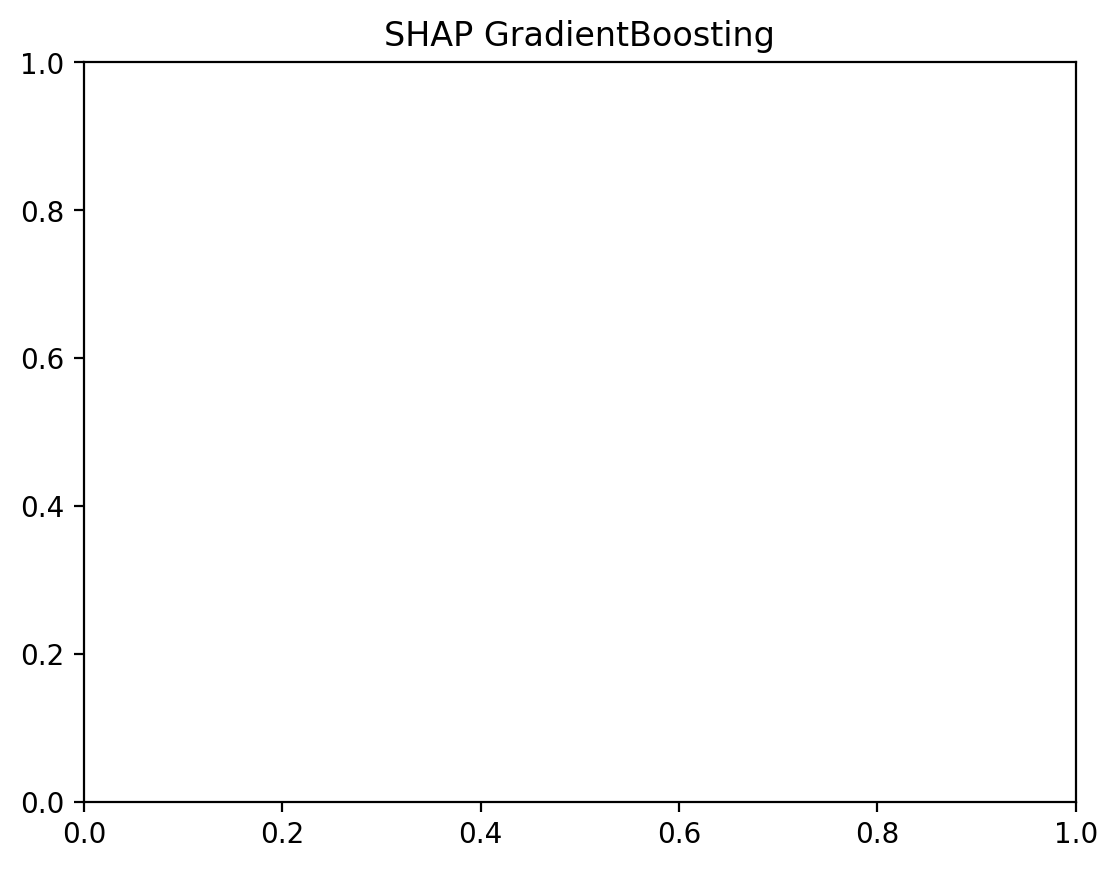

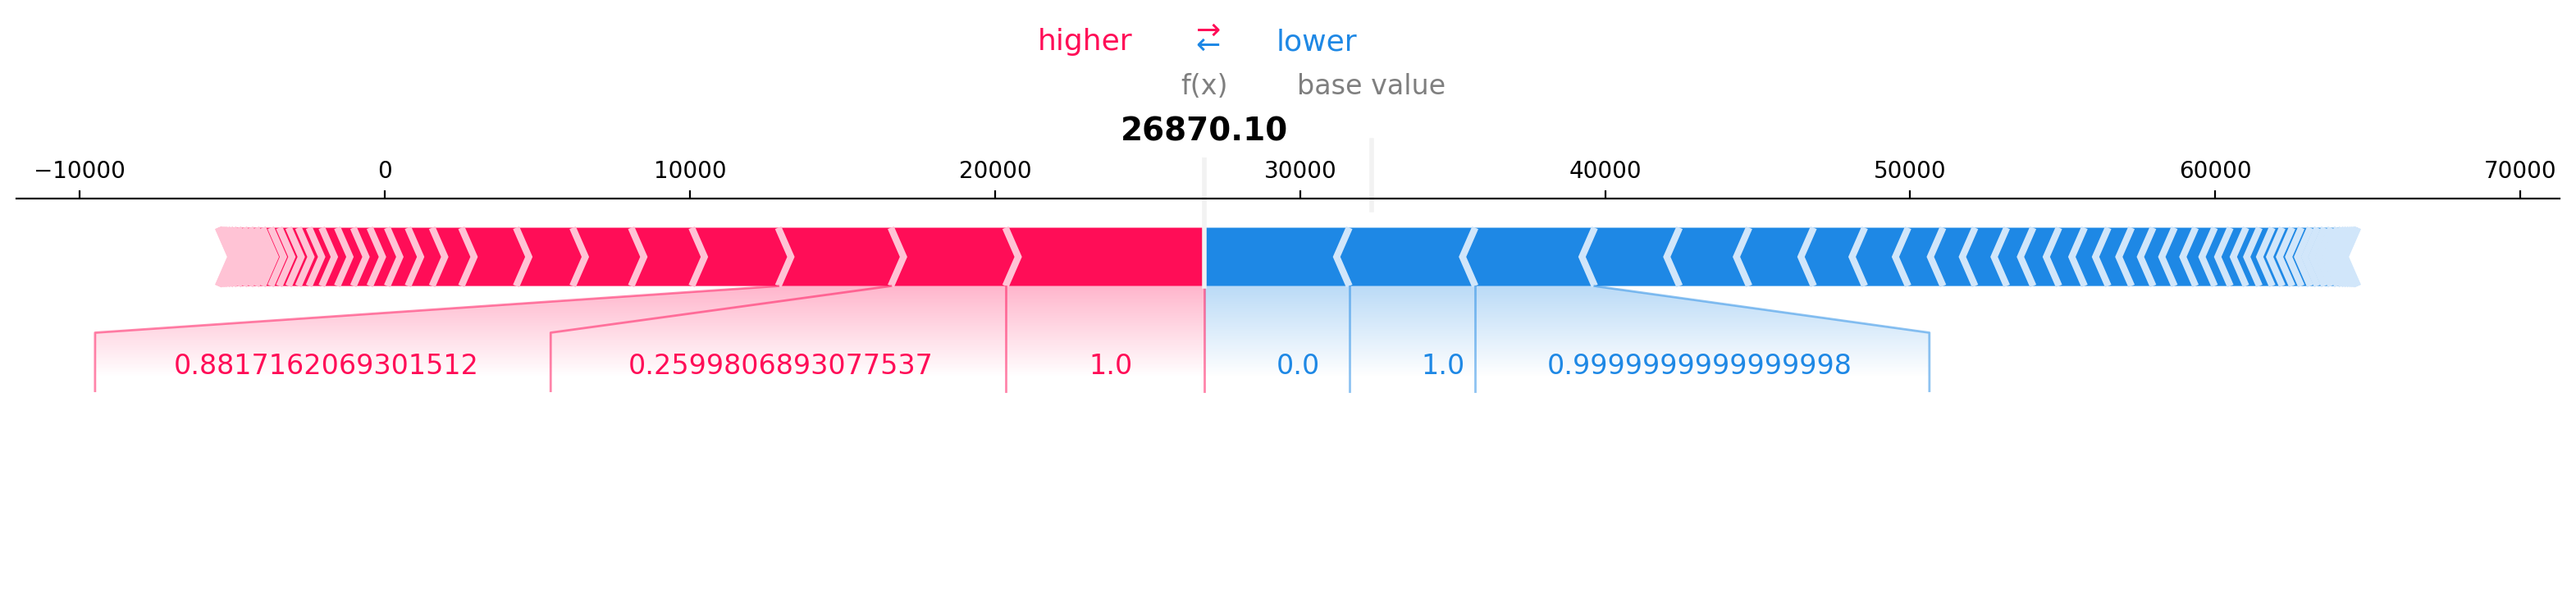

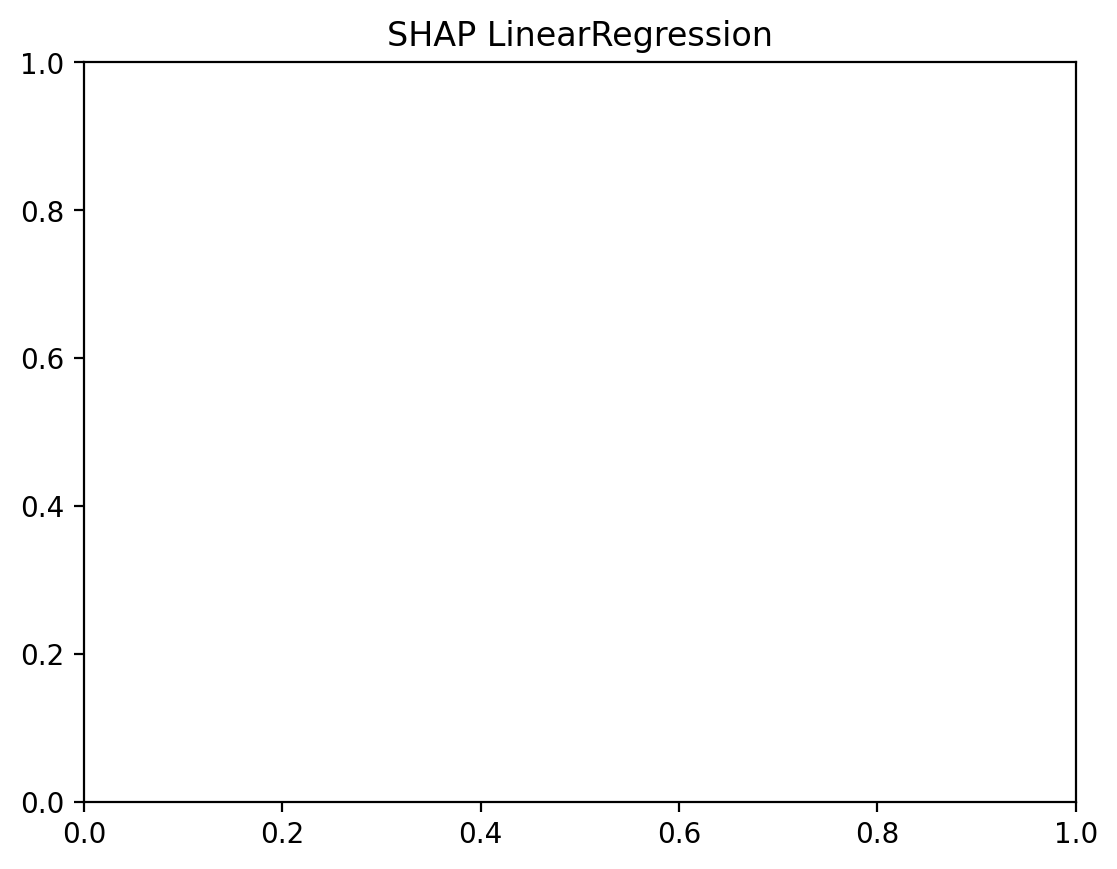

In [38]:
import shap

explainer_gb = shap.TreeExplainer(gb_mm)
explainer_lin = shap.LinearExplainer(lin_mm, X_train_mm)

student_index = 0

x_sample = X_test_mm[student_index : student_index + 1]

shap_values_gb = explainer_gb.shap_values(x_sample)[0]
shap_values_lin = explainer_lin.shap_values(x_sample)[0]

shap.initjs()

shap.force_plot(
    explainer_gb.expected_value,
    shap_values_gb,
    x_sample[0],
    matplotlib=True,
)
plt.title("SHAP GradientBoosting")
plt.show()

shap.force_plot(
    explainer_lin.expected_value,
    shap_values_lin,
    x_sample[0],
    matplotlib=True,
)
plt.title("SHAP LinearRegression")
plt.show()